# SemEval 2026 Task 5: Narrative Plausibility Prediction with DeBERTa-v3-large + LoRA + CORAL

## Expert Strategic Implementation

**Goal**: Achieve Spearman ρ ≥ 0.85 and ACC within SD ≥ 0.85

### Task Overview
Predict human-perceived plausibility ratings (1.0 to 5.0) for word senses within narrative contexts using:
- **Model**: DeBERTa-v3-large (304M parameters)
- **Efficiency**: LoRA (Low-Rank Adaptation) for PEFT
- **Loss**: CORAL (COnsistent RAnk Logits) for ordinal regression
- **Strategy**: Metric-specific optimization with early stopping

### Key Challenges
1. **Limited Data**: 2,280 training samples → Risk of overfitting
2. **Ordinal Nature**: Ratings have inherent order (predicting 1 instead of 5 is worse than 4 instead of 5)
3. **Resource Constraints**: 8GB VRAM requires parameter-efficient training
4. **Metric Alignment**: Must optimize for Spearman correlation (rank-based) not just MSE

### Implementation Plan
- **Phase 1**: Baseline with QLoRA + CORAL loss
- **Phase 2**: Ensemble + Data Augmentation (if resources allow)


## 1. Environment Setup & Library Imports


In [ ]:
# ===== CRITICAL: Disable problematic progress bars BEFORE any imports =====
import os
os.environ['HF_HUB_DISABLE_PROGRESS_BARS'] = '1'
os.environ['TRANSFORMERS_VERBOSITY'] = 'error'
os.environ['HF_HUB_DISABLE_EXPERIMENTAL_WARNING'] = '1'

# Core libraries
import json
# import math
import random
import re
import warnings
from pathlib import Path
from typing import Dict, List, Optional, Tuple

# Data processing & visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch
import torch
from torch.optim import AdamW
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# Transformers & PEFT
from transformers import (
    AutoModel, 
    AutoTokenizer, 
    # AutoConfig,
    # AdamW,
    get_linear_schedule_with_warmup,
    get_cosine_schedule_with_warmup
)
from peft import (
    LoraConfig, 
    get_peft_model, 
    # TaskType,
    # prepare_model_for_kbit_training
)

# Metrics
from scipy.stats import spearmanr
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Progress bars
from tqdm.auto import tqdm

# Configuration
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✓ Using device: {device}")
if torch.cuda.is_available():
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

print("\n✓ All libraries imported successfully")


✓ Using device: cuda
  GPU: NVIDIA GeForce RTX 4060 Laptop GPU
  VRAM: 7.6 GB

✓ All libraries imported successfully


## 2. Configuration - Two-Phase Strategy


In [14]:
# Configuration for SemEval 2026 Task 5
config = {
    # ===== MODEL CONFIGURATION =====
    'model_name': 'microsoft/deberta-v3-large',  # 304M parameters, SOTA for NLU
    'max_length': 512,  # Balanced: good context, fits in 8GB VRAM
    'pooling': 'weighted',  # 'cls', 'mean', or 'weighted'
    'gradient_checkpointing': False,  # Disabled for faster training (we have enough VRAM)
    'use_amp': True,  # Mixed precision training (FP16) - faster AND saves VRAM
    
    # ===== LoRA CONFIGURATION (PEFT) =====
    'use_lora': True,
    'lora_r': 32,  # RESTORED - this worked best
    'lora_alpha': 128,  # Scaling factor (4x rank)
    'lora_dropout': 0.05,  # RESTORED - was over-regularizing
    'lora_target_modules': ['query_proj', 'key_proj', 'value_proj', 'dense'],
    
    # ===== ORDINAL REGRESSION =====
    'loss_type': 'hybrid',  # Options: coral, mse, hybrid, huber
    'num_classes': 5,  # Ratings 1-5
    
    'coral_weight_start': 1.0,  # CORAL weight at epoch 1 (for hybrid)                1. DynaOrd
    'coral_weight_end': 0.7,   # CORAL weight at final epoch (for hybrid)
    'huber_weight_start': 0.1,  # Huber weight at epoch 1 (for hybrid)
    'huber_weight_end': 0.4,   # Huber weight at final epoch (for hybrid)

    # 'coral_weight_start': 1.1,  # CORAL weight at epoch 1 (for hybrid)                2. coral
    # 'coral_weight_end': 1.1,   # CORAL weight at final epoch (for hybrid)
    # 'huber_weight_start': 0.0,  # Huber weight at epoch 1 (for hybrid)
    # 'huber_weight_end': 0.0,   # Huber weight at final epoch (for hybrid)

    # 'coral_weight_start': 0.0,  # CORAL weight at epoch 1 (for hybrid)                3. mse 
    # 'coral_weight_end': 0.0,   # CORAL weight at final epoch (for hybrid)
    # 'huber_weight_start': 1.1,  # Huber weight at epoch 1 (for hybrid)
    # 'huber_weight_end': 1.1,   # Huber weight at final epoch (for hybrid)

    # 'coral_weight_start': 1.0,  # CORAL weight at epoch 1 (for hybrid)                4. conservative
    # 'coral_weight_end': 0.8,   # CORAL weight at final epoch (for hybrid)
    # 'huber_weight_start': 0.1,  # Huber weight at epoch 1 (for hybrid)
    # 'huber_weight_end': 0.3,   # Huber weight at final epoch (for hybrid)

    # 'coral_weight_start': 1.0,  # CORAL weight at epoch 1 (for hybrid)                5. aggressive
    # 'coral_weight_end': 0.6,   # CORAL weight at final epoch (for hybrid)
    # 'huber_weight_start': 0.1,  # Huber weight at epoch 1 (for hybrid)
    # 'huber_weight_end': 0.5,   # Huber weight at final epoch (for hybrid)

    # 'coral_weight_start': 0.1,  # CORAL weight at epoch 1 (for hybrid)                6. inverted
    # 'coral_weight_end': 0.4,   # CORAL weight at final epoch (for hybrid)
    # 'huber_weight_start': 1.0,  # Huber weight at epoch 1 (for hybrid)
    # 'huber_weight_end': 0.7,   # Huber weight at final epoch (for hybrid)

    # 'coral_weight_start': 1.0,  # CORAL weight at epoch 1 (for hybrid)                7. huber
    # 'coral_weight_end': 0.7,   # CORAL weight at final epoch (for hybrid)
    # 'huber_weight_start': 0.1,  # Huber weight at epoch 1 (for hybrid)
    # 'huber_weight_end': 0.4,   # Huber weight at final epoch (for hybrid)

    # 'coral_weight_start': 0.9,  # CORAL weight at epoch 1 (for hybrid)                8. static v1
    # 'coral_weight_end': 0.9,   # CORAL weight at final epoch (for hybrid)
    # 'huber_weight_start': 0.2,  # Huber weight at epoch 1 (for hybrid)
    # 'huber_weight_end': 0.2,   # Huber weight at final epoch (for hybrid)

    # 'coral_weight_start': 0.8,  # CORAL weight at epoch 1 (for hybrid)                9. static v2
    # 'coral_weight_end': 0.8,   # CORAL weight at final epoch (for hybrid)
    # 'huber_weight_start': 0.3,  # Huber weight at epoch 1 (for hybrid)
    # 'huber_weight_end': 0.3,   # Huber weight at final epoch (for hybrid)

    # 'coral_weight_start': 0.6,  # CORAL weight at epoch 1 (for hybrid)                10. static v3
    # 'coral_weight_end': 0.6,   # CORAL weight at final epoch (for hybrid)
    # 'huber_weight_start': 0.5,  # Huber weight at epoch 1 (for hybrid)
    # 'huber_weight_end': 0.5,   # Huber weight at final epoch (for hybrid)


    'use_huber': False,  # Use Huber instead of MSE in hybrid mode
    'huber_delta': 1.0,  # Huber loss delta
    # 'ordinal_weight': 1.0,
    # 'mse_weight': 0.3,
    
    # ===== TRAINING HYPERPARAMETERS =====
    'learning_rate': 8e-5,  # RESTORED - model needs this to learn
    'epochs': 10,  # RESTORED
    'batch_size': 2, # 6 for p100 or t4 gpu
    'grad_accumulation_steps': 8,  # Effective batch size = 16         # 4 for p100 or t4 gpu
    'weight_decay': 0.15,  # RESTORED - was too high
    'warmup_ratio': 0.05,  # RESTORED
    'scheduler_type': 'cosine',  # RESTORED - this is what worked!
    
    # ===== REGULARIZATION =====
    'dropout': 0.4,  # RESTORED - was too aggressive
    'label_smoothing': 0.0,
    'gradient_clip': 1.0,
    
    # ===== EARLY STOPPING =====
    'early_stop_patience': 3,  # RESTORED
    'early_stop_metric': 'combined',  # Optimize BOTH metrics
    
    # ===== DATA PATHS =====
    'train_path': 'train.json',
    'dev_path': 'dev.json',
    
    # ===== OUTPUT =====
    'save_dir': 'outputs',
    'model_save_prefix': 'deberta_coral',  # Filename will be: {prefix}_{date}_spear{spearman}_acc{acc}.pt
    'seed': 42,
}

# Set random seeds
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True

set_seed(config['seed'])

# Create output directory
os.makedirs(config['save_dir'], exist_ok=True)

print("=" * 80)
print("CONFIGURATION SUMMARY")
print("=" * 80)
print(f"\n Model: {config['model_name']}")
print(f" Loss: {config['loss_type'].upper()} (Ordinal Regression)")
print(f" LoRA Rank: {config['lora_r']} (Trainable params: ~{config['lora_r'] * 2 * 1024 * 24 / 1e6:.1f}M)")
print(f" Effective Batch Size: {config['batch_size'] * config['grad_accumulation_steps']}")
print(f" Epochs: {config['epochs']} (Early stop patience: {config['early_stop_patience']})")
print(f" Learning Rate: {config['learning_rate']}")
print(f" Seed: {config['seed']}")

# VRAM optimizations
print(f"\n VRAM OPTIMIZATIONS (for 8GB RTX 4060):")
print(f"   • Batch size: {config['batch_size']} (target: ~6.5GB VRAM, safe with memory clearing)")
print(f"   • Max length: {config['max_length']} (balanced for context + VRAM)")
print(f"   • Gradient checkpointing: {config.get('gradient_checkpointing', False)} (disabled for speed)")
print(f"   • Mixed precision (AMP): {config.get('use_amp', False)} (faster + saves VRAM)")
print(f"   • Gradient accumulation: {config['grad_accumulation_steps']} steps (effective batch: {config['batch_size'] * config['grad_accumulation_steps']})")
print(f"   • Aggressive memory clearing: enabled (prevents accumulation across epochs)")

print("\n✓ Configuration loaded")


CONFIGURATION SUMMARY

 Model: microsoft/deberta-v3-large
 Loss: HYBRID (Ordinal Regression)
 LoRA Rank: 32 (Trainable params: ~1.6M)
 Effective Batch Size: 16
 Epochs: 10 (Early stop patience: 3)
 Learning Rate: 8e-05
 Seed: 42

 VRAM OPTIMIZATIONS (for 8GB RTX 4060):
   • Batch size: 2 (target: ~6.5GB VRAM, safe with memory clearing)
   • Max length: 512 (balanced for context + VRAM)
   • Gradient checkpointing: False (disabled for speed)
   • Mixed precision (AMP): True (faster + saves VRAM)
   • Gradient accumulation: 8 steps (effective batch: 16)
   • Aggressive memory clearing: enabled (prevents accumulation across epochs)

✓ Configuration loaded


## 3. Data Loading & Exploration


In [15]:
def load_json_dataset(filepath: str) -> pd.DataFrame:
    """Load dataset from JSON file"""
    with open(filepath, 'r') as f:
        data = json.load(f)
    
    rows = []
    for key, item in data.items():
        row = item.copy()
        row['id'] = key
        rows.append(row)
    
    df = pd.DataFrame(rows)
    
    # Standardize columns
    text_cols = ['homonym', 'judged_meaning', 'precontext', 'sentence', 
                 'ending', 'example_sentence', 'sense_tags', 'sense_synonyms']
    for col in text_cols:
        if col not in df.columns:
            df[col] = ''
        df[col] = df[col].fillna('')
    
    # Numeric columns
    df['average'] = df['average'].astype(float)  # Target: 1.0 to 5.0
    df['stdev'] = df['stdev'].astype(float)
    
    return df

# Load datasets
print("\n" + "=" * 80)
print("LOADING DATASETS")
print("=" * 80)

train_df = load_json_dataset(config['train_path'])
dev_df = load_json_dataset(config['dev_path'])

print(f"\n✓ Training set: {len(train_df)} samples")
print(f"✓ Development set: {len(dev_df)} samples")

# Display statistics
print(f"\n Training Data Statistics:")
print(f"   Average rating: {train_df['average'].mean():.3f} ± {train_df['average'].std():.3f}")
print(f"   Range: [{train_df['average'].min():.1f}, {train_df['average'].max():.1f}]")
print(f"   Mean stdev: {train_df['stdev'].mean():.3f}")

print(f"\n Development Data Statistics:")
print(f"   Average rating: {dev_df['average'].mean():.3f} ± {dev_df['average'].std():.3f}")
print(f"   Range: [{dev_df['average'].min():.1f}, {dev_df['average'].max():.1f}]")
print(f"   Mean stdev: {dev_df['stdev'].mean():.3f}")

# Show sample
print(f"\n Sample Entry:")
print(f"   ID: {train_df.iloc[0]['id']}")
print(f"   Homonym: '{train_df.iloc[0]['homonym']}'")
print(f"   Meaning: '{train_df.iloc[0]['judged_meaning'][:80]}...'")
print(f"   Average: {train_df.iloc[0]['average']:.1f}")
print(f"   Stdev: {train_df.iloc[0]['stdev']:.2f}")



LOADING DATASETS

✓ Training set: 2280 samples
✓ Development set: 588 samples

 Training Data Statistics:
   Average rating: 3.140 ± 1.187
   Range: [1.0, 5.0]
   Mean stdev: 0.948

 Development Data Statistics:
   Average rating: 3.118 ± 1.186
   Range: [1.0, 5.0]
   Mean stdev: 0.949

 Sample Entry:
   ID: 0
   Homonym: 'potential'
   Meaning: 'the difference in electrical charge between two points in a circuit expressed in...'
   Average: 3.0
   Stdev: 1.58


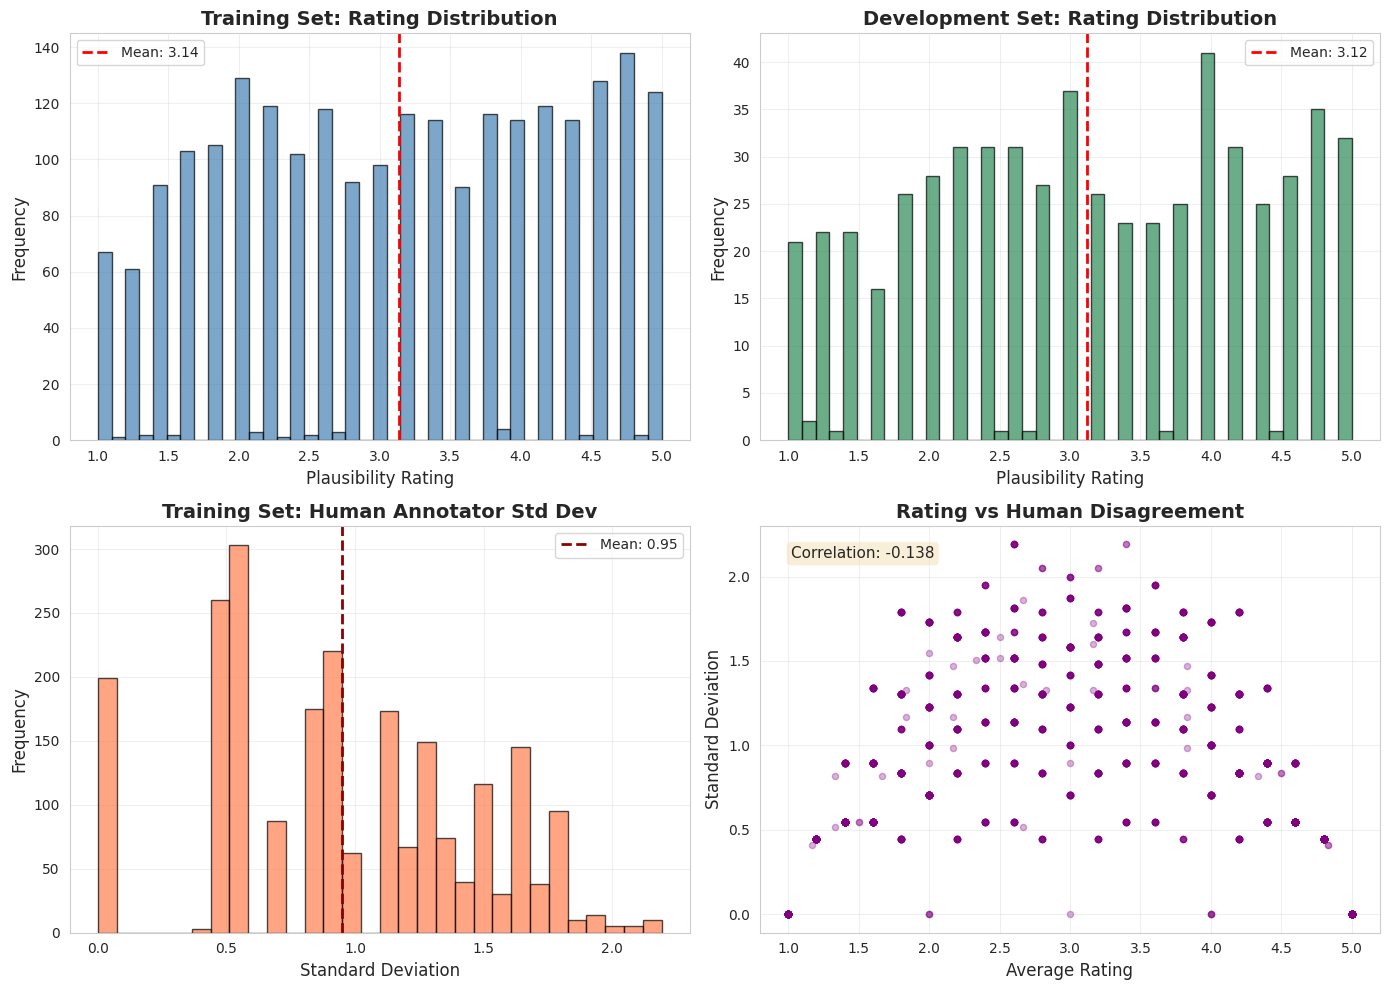


✓ Data exploration plots saved to 'data_exploration.png'


In [16]:
# Visualize data distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Rating distribution (Training)
axes[0, 0].hist(train_df['average'], bins=41, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].axvline(train_df['average'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {train_df['average'].mean():.2f}')
axes[0, 0].set_xlabel('Plausibility Rating', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].set_title('Training Set: Rating Distribution', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Plot 2: Rating distribution (Dev)
axes[0, 1].hist(dev_df['average'], bins=41, edgecolor='black', alpha=0.7, color='seagreen')
axes[0, 1].axvline(dev_df['average'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {dev_df['average'].mean():.2f}')
axes[0, 1].set_xlabel('Plausibility Rating', fontsize=12)
axes[0, 1].set_ylabel('Frequency', fontsize=12)
axes[0, 1].set_title('Development Set: Rating Distribution', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Plot 3: Standard deviation distribution
axes[1, 0].hist(train_df['stdev'], bins=30, edgecolor='black', alpha=0.7, color='coral')
axes[1, 0].axvline(train_df['stdev'].mean(), color='darkred', linestyle='--', linewidth=2, label=f'Mean: {train_df['stdev'].mean():.2f}')
axes[1, 0].set_xlabel('Standard Deviation', fontsize=12)
axes[1, 0].set_ylabel('Frequency', fontsize=12)
axes[1, 0].set_title('Training Set: Human Annotator Std Dev', fontsize=14, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Plot 4: Rating vs Stdev scatter
axes[1, 1].scatter(train_df['average'], train_df['stdev'], alpha=0.3, s=20, color='purple')
axes[1, 1].set_xlabel('Average Rating', fontsize=12)
axes[1, 1].set_ylabel('Standard Deviation', fontsize=12)
axes[1, 1].set_title('Rating vs Human Disagreement', fontsize=14, fontweight='bold')
axes[1, 1].grid(alpha=0.3)
axes[1, 1].text(0.05, 0.95, f'Correlation: {train_df["average"].corr(train_df["stdev"]):.3f}',
                transform=axes[1, 1].transAxes, fontsize=11, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('data_exploration.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Data exploration plots saved to 'data_exploration.png'")


## 4. Input Formatting for DeBERTa

Following the strategic plan: hierarchical encoding with explicit structure information


In [17]:
def highlight_target(sentence: str, homonym: str) -> str:
    """Highlight target word with [TGT] tags"""
    if not sentence or '[TGT]' in sentence or not homonym:
        return sentence
    pattern = re.compile(rf"\b{re.escape(homonym)}\b", re.IGNORECASE)
    return pattern.sub(lambda m: f"[TGT]{m.group(0)}[/TGT]", sentence, count=1)

def create_narrative_input(row: pd.Series, mark_homonym: bool = True) -> str:
    """
    Create structured input for DeBERTa following the strategic plan.
    
    Format: Provides hierarchical context from word-level to document-level
    - Ambiguous word + candidate sense
    - Dictionary example (word-level context)
    - Story context (sentence/paragraph-level)
    - Target sentence (where the word appears)
    - Ending (document-level closure)
    """
    sentence = row['sentence']
    if mark_homonym:
        sentence = highlight_target(sentence, row.get('homonym', ''))
    
    parts = [
        f"Ambiguous word: {row.get('homonym', '').strip()}.",
        f"Candidate sense: {row.get('judged_meaning', '').strip()}."
    ]
    
    # Add sense tags if available
    tags = row.get('sense_tags', '').strip()
    if tags:
        parts.append(f"Sense tags: {tags}.")
    
    # Add dictionary example (provides canonical usage)
    example = row.get('example_sentence', '').strip()
    if example:
        parts.append(f"Dictionary example: {example}")
    
    # Add story precontext (narrative background)
    precontext = row.get('precontext', '').strip()
    if precontext:
        parts.append(f"Story context: {precontext}")
    
    # Target sentence (most important)
    parts.append(f"Target sentence: {sentence}")
    
    # Add ending (narrative closure)
    ending = row.get('ending', '').strip()
    if ending:
        parts.append(f"Ending: {ending}")
    
    return " ".join([p for p in parts if p])

# Apply formatting
print("=" * 80)
print("FORMATTING INPUTS")
print("=" * 80)

train_df['text'] = train_df.apply(lambda row: create_narrative_input(row, mark_homonym=True), axis=1)
dev_df['text'] = dev_df.apply(lambda row: create_narrative_input(row, mark_homonym=True), axis=1)

print(f"\n✓ Training samples formatted: {len(train_df)}")
print(f"✓ Development samples formatted: {len(dev_df)}")

# Show example
print(f"\n Example Formatted Input:")
print(f"\n{train_df.iloc[0]['text']}")
print(f"\nTarget Rating: {train_df.iloc[0]['average']:.1f} (±{train_df.iloc[0]['stdev']:.2f})")

# Analyze text lengths
train_df['text_length'] = train_df['text'].str.split().str.len()
dev_df['text_length'] = dev_df['text'].str.split().str.len()

print(f"\n Text Length Statistics:")
print(f"   Training - Mean: {train_df['text_length'].mean():.1f} words, Max: {train_df['text_length'].max()} words")
print(f"   Dev - Mean: {dev_df['text_length'].mean():.1f} words, Max: {dev_df['text_length'].max()} words")
print(f"   Samples exceeding 512 tokens: ~{(train_df['text_length'] > 400).sum()} (estimate)")



FORMATTING INPUTS

✓ Training samples formatted: 2280
✓ Development samples formatted: 588

 Example Formatted Input:

Ambiguous word: potential. Candidate sense: the difference in electrical charge between two points in a circuit expressed in volts. Dictionary example: The circuit has a high potential difference. Story context: The old machine hummed in the corner of the workshop. Clara examined its dusty dials with a furrowed brow. She wondered if it could be brought back to life. Target sentence: The [TGT]potential[/TGT] couldn't be measured. Ending: She collected a battery reader and looked on earnestly, willing some life back into the old machine.

Target Rating: 3.0 (±1.58)

 Text Length Statistics:
   Training - Mean: 77.4 words, Max: 119 words
   Dev - Mean: 77.4 words, Max: 115 words
   Samples exceeding 512 tokens: ~0 (estimate)


## 5. Understanding CORAL Ordinal Regression

**Why CORAL?**
- Standard classification treats 1 and 5 as equally distant as 4 and 5 (WRONG!)
- Standard regression doesn't enforce rank consistency
- CORAL transforms ordinal problem into K-1 binary tasks with shared weights

**CORAL Framework:**
- For 5 classes (ratings 1-5), we create 4 binary classifiers:
  - Task 1: Is rating > 1? (2,3,4,5 vs 1)
  - Task 2: Is rating > 2? (3,4,5 vs 1,2)
  - Task 3: Is rating > 3? (4,5 vs 1,2,3)
  - Task 4: Is rating > 4? (5 vs 1,2,3,4)

**Key Insight:** By using shared weights + individual biases, we enforce rank consistency while learning the ordinal structure.


In [18]:
class PlausibilityDataset(Dataset):
    """Dataset for narrative plausibility rating"""
    
    def __init__(self, texts: List[str], scores: List[float], stdevs: List[float], 
                 tokenizer, max_length: int):
        self.texts = texts
        self.scores = scores  # Continuous 1.0 to 5.0
        self.stdevs = stdevs
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'score': torch.tensor(self.scores[idx], dtype=torch.float),
            'stdev': torch.tensor(self.stdevs[idx], dtype=torch.float)
        }

print("✓ Dataset class defined")


✓ Dataset class defined


## 6. CORAL Model Architecture with LoRA


In [19]:
class CORALModel(nn.Module):
    """
    DeBERTa-v3-large with CORAL ordinal regression head
    
    Architecture:
    - DeBERTa encoder (with LoRA)
    - Pooling layer (CLS, mean, or weighted attention)
    - CORAL head: K-1 binary classifiers with shared weights + individual biases
    """
    
    def __init__(self, encoder, num_classes=5, pooling='cls', dropout=0.3):
        super().__init__()
        self.encoder = encoder
        self.pooling_type = pooling
        self.num_classes = num_classes
        
        hidden_size = encoder.config.hidden_size
        
        # Weighted attention pooling (optional)
        if pooling == 'weighted':
            self.attention_weights = nn.Linear(hidden_size, 1)
        
        # Dropout for regularization
        self.dropout = nn.Dropout(dropout)
        
        # CORAL head: shared weight + K-1 biases
        # For K=5 classes (1,2,3,4,5), we need 4 binary classifiers
        self.coral_linear = nn.Linear(hidden_size, 1, bias=False)
        # Initialize biases to encourage full range predictions (1.0 to 5.0)
        # Wider range helps model predict extreme values
        # initial_biases = torch.linspace(-2.0, 2.0, num_classes - 1)
        initial_biases = torch.linspace(-1.0, 1.0, num_classes - 1)
        self.coral_bias = nn.Parameter(initial_biases)
        
    def forward(self, input_ids, attention_mask):
        # Get encoder outputs
        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_dict=True
        )
        hidden_states = outputs.last_hidden_state  # (batch, seq_len, hidden)
        
        # Pooling
        if self.pooling_type == 'cls':
            # Use [CLS] token
            pooled = hidden_states[:, 0, :]
        elif self.pooling_type == 'mean':
            # Mean pooling with attention mask
            mask = attention_mask.unsqueeze(-1).float()
            pooled = (hidden_states * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)
        elif self.pooling_type == 'weighted':
            # Attention-weighted pooling
            attn_scores = self.attention_weights(hidden_states).squeeze(-1)
            # BEST - uses tensor's own dtype
            attn_scores = attn_scores.masked_fill(attention_mask == 0, torch.finfo(attn_scores.dtype).min)
            attn_weights = F.softmax(attn_scores, dim=1)
            pooled = (hidden_states * attn_weights.unsqueeze(-1)).sum(dim=1)
        else:
            pooled = hidden_states[:, 0, :]
        
        pooled = self.dropout(pooled)
        
        # CORAL logits: shared weight applied to pooled, then add individual biases
        logits = self.coral_linear(pooled)  # (batch, 1)
        logits = logits + self.coral_bias  # (batch, K-1) via broadcasting
        
        return logits  # (batch, num_classes-1)


def coral_loss(logits, labels, num_classes=5, label_smoothing=0.0):
    """
    CORAL ordinal regression loss with soft targets for continuous labels
    
    Args:
        logits: (batch, K-1) - outputs from CORAL head
        labels: (batch,) - continuous ratings 1.0 to 5.0
        num_classes: K=5 (ratings 1-5)
        label_smoothing: float - smoothing factor (0.05 means 0->0.05, 1->0.95)
    
    Returns:
        loss: scalar
    """
    # Convert continuous labels to ordinal targets with soft boundaries
    # For rating r, we want soft targets:
    #   - Task 1 (>1): 1 if r >= 2, else max(0, r-1) for fractional
    #   - Task 2 (>2): 1 if r >= 3, else max(0, r-2) for fractional
    #   - Task 3 (>3): 1 if r >= 4, else max(0, r-3) for fractional
    #   - Task 4 (>4): 1 if r >= 5, else max(0, r-4) for fractional
    
    levels = torch.arange(1, num_classes, dtype=torch.float32, device=labels.device)
    
    # Create soft binary targets: (batch, K-1)
    # For continuous labels, use soft boundaries
    labels_expanded = labels.unsqueeze(1)  # (batch, 1)
    levels_expanded = levels.unsqueeze(0)   # (1, K-1)
    
    # Soft targets: 
    # - If label >= level+1: target = 1.0
    # - If label < level: target = 0.0
    # - If level <= label < level+1: target = label - level (fractional)
    # Example: label=3.5, levels=[1,2,3,4] -> targets=[1.0, 1.0, 0.5, 0.0]
    diff = labels_expanded - levels_expanded  # (batch, K-1)
    targets = torch.clamp(diff, min=0.0, max=1.0)
    
    # Apply label smoothing: prevents overconfident predictions
    # Moves 0 -> smoothing, 1 -> (1 - smoothing)
    if label_smoothing > 0:
        targets = targets * (1 - label_smoothing) + 0.5 * label_smoothing
    
    # Binary cross-entropy for each task
    loss = F.binary_cross_entropy_with_logits(logits, targets, reduction='mean')
    
    return loss


def coral_predict(logits):
    """
    Convert CORAL logits to predicted ratings
    
    Args:
        logits: (batch, K-1) - raw CORAL outputs
    
    Returns:
        predictions: (batch,) - ratings in range [1, 5]
    """
    # Apply sigmoid to get probabilities
    probs = torch.sigmoid(logits)
    
    # Sum of probabilities + 1 gives the predicted rating
    # E.g., if all probs are ~1, sum = 4, rating = 5
    # If all probs are ~0, sum = 0, rating = 1
    predictions = 1 + probs.sum(dim=1)
    
    # Clamp to valid range
    predictions = torch.clamp(predictions, min=1.0, max=5.0)
    
    return predictions


print("✓ CORAL model and loss function defined")


✓ CORAL model and loss function defined


## 7. Training & Evaluation Functions


In [20]:
def calculate_metrics(predictions, targets, stdevs):
    """Calculate all evaluation metrics"""
    predictions = np.array(predictions)
    targets = np.array(targets)
    stdevs = np.array(stdevs)
    
    # Spearman correlation (primary metric)
    spearman_corr, p_value = spearmanr(predictions, targets)
    
    # Accuracy within standard deviation
    within_sd = np.abs(predictions - targets) <= np.maximum(stdevs, 1.0)
    acc_within_sd = np.mean(within_sd)
    
    # Other metrics
    mse = mean_squared_error(targets, predictions)
    mae = mean_absolute_error(targets, predictions)
    rmse = np.sqrt(mse)
    
    return {
        'spearman': float(spearman_corr),
        'spearman_pvalue': float(p_value),
        'acc_within_sd': float(acc_within_sd),
        'mse': float(mse),
        'mae': float(mae),
        'rmse': float(rmse)
    }


def train_one_epoch(model, dataloader, optimizer, scheduler, device, grad_accum_steps, 
                    loss_type='coral', gradient_clip=None, use_amp=False, 
                    coral_weight_start=1.0, coral_weight_end=0.7,
                    huber_weight_start=0.1, huber_weight_end=0.4,
                    epoch=0, total_epochs=8,
                    use_huber=True, huber_delta=0.5, label_smoothing=0.0):
    """Train for one epoch with NORMALIZED dynamic loss weighting
    
    Normalized weighting keeps total loss magnitude stable:
    - Early epochs: CORAL high (1.0), Huber low (0.1) → total ~1.1
    - Later epochs: CORAL lower (0.7), Huber higher (0.4) → total ~1.1
    
    This prevents loss explosion that destabilizes training.
    """
    # Calculate dynamic weights (linear interpolation)
    progress = epoch / max(total_epochs - 1, 1)  # 0 to 1
    coral_weight = coral_weight_start + (coral_weight_end - coral_weight_start) * progress
    huber_weight = huber_weight_start + (huber_weight_end - huber_weight_start) * progress
    model.train()
    total_loss = 0.0
    all_predictions = []
    all_targets = []
    
    # Mixed precision scaler
    scaler = torch.cuda.amp.GradScaler() if use_amp and torch.cuda.is_available() else None
    
    optimizer.zero_grad()
    
    # Clear cache at start
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    
    pbar = tqdm(dataloader, desc="Training", leave=False)
    for step, batch in enumerate(pbar):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        scores = batch['score'].to(device)
        
        # Forward pass with mixed precision
        if use_amp and scaler is not None:
            with torch.cuda.amp.autocast():
                logits = model(input_ids, attention_mask)
                
                # Calculate loss
                if loss_type == 'coral':
                    loss = coral_loss(logits, scores, num_classes=5, label_smoothing=label_smoothing)
                    with torch.no_grad():
                        preds = coral_predict(logits)
                elif loss_type == 'mse':
                    # Use coral_predict since model outputs CORAL logits (batch, 4)
                    preds = coral_predict(logits)
                    loss = F.mse_loss(preds, scores)
                elif loss_type == 'huber':
                    preds = coral_predict(logits)  # Get predictions from CORAL head
                    loss = F.huber_loss(preds, scores, delta=huber_delta)
                elif loss_type == 'hybrid':
                    # Hybrid: CORAL (ranking) + Huber (calibration) with NORMALIZED dynamic weighting
                    coral_loss_val = coral_loss(logits, scores, num_classes=5, label_smoothing=label_smoothing)
                    preds = coral_predict(logits)
                    if use_huber:
                        reg_loss_val = F.huber_loss(preds, scores, delta=huber_delta)
                    else:
                        reg_loss_val = F.mse_loss(preds, scores)
                    loss = coral_weight * coral_loss_val + huber_weight * reg_loss_val
                else:
                    raise ValueError(f"Unknown loss type: {loss_type}")
            
            # Backward pass with gradient accumulation (AMP)
            loss = loss / grad_accum_steps
            scaler.scale(loss).backward()
        else:
            # Standard precision
            logits = model(input_ids, attention_mask)
            
            # Calculate loss
            if loss_type == 'coral':
                loss = coral_loss(logits, scores, num_classes=5, label_smoothing=label_smoothing)
                with torch.no_grad():
                    preds = coral_predict(logits)
            elif loss_type == 'mse':
                # Use coral_predict since model outputs CORAL logits (batch, 4)\n",
                preds = coral_predict(logits)
                loss = F.mse_loss(preds, scores)
            elif loss_type == 'huber':
                preds = coral_predict(logits)  # Get predictions from CORAL head
                loss = F.huber_loss(preds, scores, delta=huber_delta)
            elif loss_type == 'hybrid':
                # Hybrid: CORAL (ranking) + Huber (calibration) with NORMALIZED dynamic weighting
                coral_loss_val = coral_loss(logits, scores, num_classes=5, label_smoothing=label_smoothing)
                preds = coral_predict(logits)
                if use_huber:
                    reg_loss_val = F.huber_loss(preds, scores, delta=huber_delta)
                else:
                    reg_loss_val = F.mse_loss(preds, scores)
                loss = coral_weight * coral_loss_val + huber_weight * reg_loss_val
            else:
                raise ValueError(f"Unknown loss type: {loss_type}")
            
            # Backward pass with gradient accumulation
            loss = loss / grad_accum_steps
            loss.backward()
        
        if (step + 1) % grad_accum_steps == 0:
            # Gradient clipping
            if gradient_clip is not None:
                if use_amp and scaler is not None:
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), gradient_clip)
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), gradient_clip)
                    optimizer.step()
            else:
                if use_amp and scaler is not None:
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    optimizer.step()
            
            scheduler.step()
            optimizer.zero_grad()
            
            # Clear cache after every optimizer step (prevent accumulation)
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
        
        total_loss += loss.item() * grad_accum_steps
        # Move to CPU immediately and clear GPU memory
        all_predictions.extend(preds.detach().cpu().numpy())
        all_targets.extend(scores.cpu().numpy())
        
        # Delete tensors to free memory
        del preds
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        
        pbar.set_postfix({'loss': f'{loss.item() * grad_accum_steps:.4f}'})
    
    # Handle remaining gradients
    if len(dataloader) % grad_accum_steps != 0:
        if gradient_clip is not None:
            if use_amp and scaler is not None:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), gradient_clip)
                scaler.step(optimizer)
                scaler.update()
            else:
                torch.nn.utils.clip_grad_norm_(model.parameters(), gradient_clip)
                optimizer.step()
        else:
            if use_amp and scaler is not None:
                scaler.step(optimizer)
                scaler.update()
            else:
                optimizer.step()
        scheduler.step()
        optimizer.zero_grad()
    
    # Final cache clear
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    
    avg_loss = total_loss / len(dataloader)
    return avg_loss, np.array(all_predictions), np.array(all_targets)


def evaluate_model(model, dataloader, device, loss_type='coral', 
                   coral_weight=1.0, huber_weight=0.3,
                   use_huber=True, huber_delta=0.5):
    """Evaluate model on validation/test set with normalized Huber loss support"""
    model.eval()
    total_loss = 0.0
    all_predictions = []
    all_targets = []
    all_stdevs = []
    
    # Clear cache before evaluation
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    
    with torch.no_grad():
        pbar = tqdm(dataloader, desc="Evaluating", leave=False)
        for batch in pbar:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            scores = batch['score'].to(device)
            stdevs = batch['stdev'].to(device)
            
            # Forward pass
            logits = model(input_ids, attention_mask)
            
            # Calculate loss
            if loss_type == 'coral':
                loss = coral_loss(logits, scores, num_classes=5)
                preds = coral_predict(logits)
            elif loss_type == 'mse':
                # Use coral_predict since model outputs CORAL logits (batch, 4)
                preds = coral_predict(logits)
                loss = F.mse_loss(preds, scores)
            elif loss_type == 'huber':
                preds = coral_predict(logits)
                loss = F.huber_loss(preds, scores, delta=huber_delta)
            elif loss_type == 'hybrid':
                coral_loss_val = coral_loss(logits, scores, num_classes=5)
                preds = coral_predict(logits)
                if use_huber:
                    reg_loss_val = F.huber_loss(preds, scores, delta=huber_delta)
                else:
                    reg_loss_val = F.mse_loss(preds, scores)
                loss = coral_weight * coral_loss_val + huber_weight * reg_loss_val
            else:
                raise ValueError(f"Unknown loss type: {loss_type}")
            
            total_loss += loss.item()
            # Move to CPU immediately
            all_predictions.extend(preds.detach().cpu().numpy())
            all_targets.extend(scores.cpu().numpy())
            all_stdevs.extend(stdevs.cpu().numpy())
            
            # Clear cache periodically during evaluation
            if torch.cuda.is_available() and len(all_predictions) % 50 == 0:
                torch.cuda.empty_cache()
            
            # Delete tensors
            del logits, preds, loss
    
    # Final cache clear
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    
    avg_loss = total_loss / len(dataloader)
    return avg_loss, np.array(all_predictions), np.array(all_targets), np.array(all_stdevs)


print("✓ Training and evaluation functions defined")


✓ Training and evaluation functions defined


## 8. Install Required Dependencies (if needed)

**Note**: DeBERTa-v3 requires `protobuf` library. This cell installs it if missing.


In [21]:
print("=" * 80)
print("MODEL INITIALIZATION")
print("=" * 80)

# Load tokenizer (simple, like RoBERTa)
# After installing protobuf + sentencepiece in Cell 17, this should work
print(f"\n Loading tokenizer: {config['model_name']}...")

# Verify dependencies are installed
try:
    import sentencepiece
    import google.protobuf
    print("   ✓ Dependencies verified (sentencepiece, protobuf)")
except ImportError as e:
    print(f"    Missing dependency: {e}")
    print("     Run Cell 17 first to install dependencies, then restart kernel!")
    raise

# Load tokenizer
try:
    tokenizer = AutoTokenizer.from_pretrained(config['model_name'])
    print("   ✓ Tokenizer loaded successfully")
except Exception as e:
    error_msg = str(e)
    if "sentencepiece" in error_msg.lower():
        print(f"SentencePiece error: {error_msg[:200]}")
        print("Solution: Run Cell 17, restart kernel, then try again")
    elif "protobuf" in error_msg.lower():
        print(f"Protobuf error: {error_msg[:200]}")
        print("Solution: Run Cell 17, restart kernel, then try again")
    else:
        print(f"Error: {error_msg[:200]}")
    raise

# Load base model (simple, like RoBERTa)
print(f"\n Loading base model: {config['model_name']}...")
print("   (This may take several minutes - downloading ~1.5GB model)")
try:
    base_encoder = AutoModel.from_pretrained(config['model_name'])
    print("✓ Base model loaded successfully")
except Exception as e:
    print(f" Error loading model: {e}")
    raise

# Apply LoRA
if config['use_lora']:
    print(f"\n Applying LoRA (r={config['lora_r']}, alpha={config['lora_alpha']})...")
    try:
        # For DeBERTa base model, target modules should match attention structure
        lora_config = LoraConfig(
            r=config['lora_r'],
            lora_alpha=config['lora_alpha'],
            lora_dropout=config['lora_dropout'],
            target_modules=config['lora_target_modules'],
            bias="none"
        )
        base_encoder = get_peft_model(base_encoder, lora_config)
        base_encoder.print_trainable_parameters()
        print(" ✓ LoRA applied successfully")
    except Exception as e:
        print(f" Error applying LoRA: {e}")
        print(" Trying with different target modules...")
        # Try with standard attention modules
        try:
            lora_config = LoraConfig(
                r=config['lora_r'],
                lora_alpha=config['lora_alpha'],
                lora_dropout=config['lora_dropout'],
                target_modules=["query_proj", "key_proj", "value_proj", "dense"],
                bias="none"
            )
            base_encoder = get_peft_model(base_encoder, lora_config)
            base_encoder.print_trainable_parameters()
            print(" ✓ LoRA applied successfully (with fallback modules)")
        except Exception as e2:
            print(f" LoRA failed: {e2}")
            print(" Continuing without LoRA (full fine-tuning)...")
            config['use_lora'] = False

# Enable gradient checkpointing to save VRAM (if configured)
if config.get('gradient_checkpointing', False):
    print(f"\n Enabling gradient checkpointing (saves VRAM, slower training)...")
    if hasattr(base_encoder, 'gradient_checkpointing_enable'):
        base_encoder.gradient_checkpointing_enable()
    elif hasattr(base_encoder, 'base_model') and hasattr(base_encoder.base_model, 'gradient_checkpointing_enable'):
        base_encoder.base_model.gradient_checkpointing_enable()
    print("   ✓ Gradient checkpointing enabled")

# Create CORAL model
print(f"\n  Building CORAL model with {config['pooling']} pooling...")
try:
    model = CORALModel(
        encoder=base_encoder,
        num_classes=config['num_classes'],
        pooling=config['pooling'],
        dropout=config['dropout']
    ).to(device)
    print("   ✓ CORAL model built successfully")
except Exception as e:
    print(f"Error building CORAL model: {e}")
    raise

# Clear cache
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("   ✓ GPU cache cleared")

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n Model Statistics:")
print(f"   Total parameters: {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,} ({trainable_params/total_params*100:.2f}%)")
print(f"   Frozen parameters: {total_params - trainable_params:,}")

print(f"\n✓ Model initialized and moved to {device}")


MODEL INITIALIZATION

 Loading tokenizer: microsoft/deberta-v3-large...
   ✓ Dependencies verified (sentencepiece, protobuf)
   ✓ Tokenizer loaded successfully

 Loading base model: microsoft/deberta-v3-large...
   (This may take several minutes - downloading ~1.5GB model)
✓ Base model loaded successfully

 Applying LoRA (r=32, alpha=128)...
trainable params: 14,155,776 || all params: 448,167,936 || trainable%: 3.1586
 ✓ LoRA applied successfully

  Building CORAL model with weighted pooling...
   ✓ CORAL model built successfully
   ✓ GPU cache cleared

 Model Statistics:
   Total parameters: 448,169,989
   Trainable parameters: 14,157,829 (3.16%)
   Frozen parameters: 434,012,160

✓ Model initialized and moved to cuda


## 9. Create DataLoaders


In [22]:
print("=" * 80)
print("CREATING DATALOADERS")
print("=" * 80)

# Create datasets
train_dataset = PlausibilityDataset(
    texts=train_df['text'].tolist(),
    scores=train_df['average'].tolist(),
    stdevs=train_df['stdev'].tolist(),
    tokenizer=tokenizer,
    max_length=config['max_length']
)

dev_dataset = PlausibilityDataset(
    texts=dev_df['text'].tolist(),
    scores=dev_df['average'].tolist(),
    stdevs=dev_df['stdev'].tolist(),
    tokenizer=tokenizer,
    max_length=config['max_length']
)

# Create dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=config['batch_size'],
    shuffle=True,
    num_workers=0,  # Set to 0 for debugging, increase for faster loading
    pin_memory=True if torch.cuda.is_available() else False
)

dev_loader = DataLoader(
    dev_dataset,
    batch_size=config['batch_size'],
    shuffle=False,
    num_workers=0,
    pin_memory=True if torch.cuda.is_available() else False
)

print(f"\n✓ Training batches: {len(train_loader)}")
print(f"✓ Development batches: {len(dev_loader)}")
print(f"✓ Effective batch size: {config['batch_size'] * config['grad_accumulation_steps']}")


CREATING DATALOADERS

✓ Training batches: 1140
✓ Development batches: 294
✓ Effective batch size: 16


## 10. Setup Optimizer & Scheduler


In [23]:
print("=" * 80)
print("OPTIMIZER & SCHEDULER SETUP")
print("=" * 80)

# Optimizer: AdamW with weight decay
optimizer = AdamW(
    model.parameters(),
    lr=config['learning_rate'],
    weight_decay=config['weight_decay']
)

# Calculate total training steps
num_training_steps = len(train_loader) // config['grad_accumulation_steps'] * config['epochs']
num_warmup_steps = int(num_training_steps * config['warmup_ratio'])

# Scheduler
if config['scheduler_type'] == 'linear':
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=num_warmup_steps,
        num_training_steps=num_training_steps
    )
elif config['scheduler_type'] == 'cosine':
    scheduler = get_cosine_schedule_with_warmup(
        optimizer,
        num_warmup_steps=num_warmup_steps,
        num_training_steps=num_training_steps
    )
else:
    raise ValueError(f"Unknown scheduler type: {config['scheduler_type']}")

print(f"\n✓ Optimizer: AdamW")
print(f"   Learning rate: {config['learning_rate']}")
print(f"   Weight decay: {config['weight_decay']}")
print(f"\n✓ Scheduler: {config['scheduler_type']}")
print(f"   Total steps: {num_training_steps}")
print(f"   Warmup steps: {num_warmup_steps} ({config['warmup_ratio']*100:.0f}%)")


OPTIMIZER & SCHEDULER SETUP

✓ Optimizer: AdamW
   Learning rate: 8e-05
   Weight decay: 0.15

✓ Scheduler: cosine
   Total steps: 1420
   Warmup steps: 71 (5%)


## 11. Training Loop with Early Stopping


In [24]:
print("\n" + "=" * 80)
print("TRAINING WITH EARLY STOPPING")
print("=" * 80)

# Tracking metrics
history = {
    'train_loss': [],
    'val_loss': [],
    'train_spearman': [],
    'val_spearman': [],
    'train_acc_within_sd': [],
    'val_acc_within_sd': []
}

# Early stopping
best_metric = -float('inf')
best_epoch = 0
patience_counter = 0
best_model_path = None  # Will be set dynamically with date and scores

# Get today's date for filename
from datetime import datetime
today_date = datetime.now().strftime('%Y%m%d')  # Format: YYYYMMDD (e.g., 20251216)

print(f"\n Training for {config['epochs']} epochs (early stop patience: {config['early_stop_patience']})")
print(f" Early stopping metric: {config['early_stop_metric']}")

# Explain the metric
metric_explanations = {
    'combined': 'Harmonic mean of Spearman & ACC within SD (ensures both are high)',
    'weighted': 'Weighted average: 0.6*Spearman + 0.4*ACC within SD',
    'min': 'Minimum of both metrics (conservative, ensures both are good)',
    'spearman': 'Spearman correlation only (FOCUS: get this working first)',
    'acc_within_sd': 'Accuracy within SD only',
    'loss': 'Training loss'
}
if config['early_stop_metric'] in metric_explanations:
    print(f"   → {metric_explanations[config['early_stop_metric']]}")

print(f"\n Target: Spearman ≥ 0.80 AND ACC within SD ≥ 0.80")
if config['loss_type'] == 'hybrid':
    print(f" Strategy: NORMALIZED dynamic weighting - loss magnitude stays stable!")
    reg_type = "Huber" if config.get('use_huber', False) else "MSE"
    print(f"   CORAL: {config['coral_weight_start']} → {config['coral_weight_end']} | {reg_type}: {config['huber_weight_start']} → {config['huber_weight_end']}")
else:
    print(f" Loss type: {config['loss_type'].upper()}")
print("=" * 80)

# Training loop
for epoch in range(config['epochs']):
    print(f"\n{'='*80}")
    print(f"EPOCH {epoch + 1}/{config['epochs']}")
    print(f"{'='*80}")
    
    # Calculate current weights for this epoch (only used for hybrid mode)
    progress = epoch / max(config['epochs'] - 1, 1)
    current_coral_weight = config.get('coral_weight_start', 1.0) + (config.get('coral_weight_end', 0.85) - config.get('coral_weight_start', 1.0)) * progress
    current_huber_weight = config.get('huber_weight_start', 0.1) + (config.get('huber_weight_end', 0.25) - config.get('huber_weight_start', 0.1)) * progress
    
    if config['loss_type'] == 'hybrid':
        reg_type = "Huber" if config.get('use_huber', False) else "MSE"
        print(f" Weights: CORAL={current_coral_weight:.2f}, {reg_type}={current_huber_weight:.2f} (total={current_coral_weight + current_huber_weight:.2f})")
    else:
        print(f" Loss: {config['loss_type'].upper()}")
    
    # Train
    train_loss, train_preds, train_targets = train_one_epoch(
        model=model,
        dataloader=train_loader,
        optimizer=optimizer,
        scheduler=scheduler,
        device=device,
        grad_accum_steps=config['grad_accumulation_steps'],
        loss_type=config['loss_type'],
        gradient_clip=config['gradient_clip'],
        use_amp=config.get('use_amp', False),
        coral_weight_start=config['coral_weight_start'],
        coral_weight_end=config['coral_weight_end'],
        huber_weight_start=config['huber_weight_start'],
        huber_weight_end=config['huber_weight_end'],
        epoch=epoch,
        total_epochs=config['epochs'],
        use_huber=config.get('use_huber', True),
        huber_delta=config.get('huber_delta', 0.5),
        label_smoothing=config.get('label_smoothing', 0.0)
    )
    
    # Evaluate on training set (for overfitting analysis)
    train_metrics = calculate_metrics(train_preds, train_targets, train_df['stdev'].values)
    
    # Evaluate on validation set (use current epoch's weights for fair loss comparison)
    val_loss, val_preds, val_targets, val_stdevs = evaluate_model(
        model=model,
        dataloader=dev_loader,
        device=device,
        loss_type=config['loss_type'],
        coral_weight=current_coral_weight,
        huber_weight=current_huber_weight,
        use_huber=config.get('use_huber', True),
        huber_delta=config.get('huber_delta', 0.5)
    )
    val_metrics = calculate_metrics(val_preds, val_targets, val_stdevs)
    
    # Store metrics
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_spearman'].append(train_metrics['spearman'])
    history['val_spearman'].append(val_metrics['spearman'])
    history['train_acc_within_sd'].append(train_metrics['acc_within_sd'])
    history['val_acc_within_sd'].append(val_metrics['acc_within_sd'])
    
    # Print results
    print(f"\n Training Results:")
    print(f"   Loss: {train_loss:.4f}")
    print(f"   Spearman: {train_metrics['spearman']:.4f}")
    print(f"   ACC within SD: {train_metrics['acc_within_sd']:.4f}")
    print(f"   MAE: {train_metrics['mae']:.4f}")
    
    # Prediction diagnostics (first epoch only)
    if epoch == 0:
        print(f"\n Prediction Diagnostics (Epoch 1):")
        print(f"   Train preds - Mean: {train_preds.mean():.3f}, Std: {train_preds.std():.3f}, Range: [{train_preds.min():.2f}, {train_preds.max():.2f}]")
        print(f"   Train targets - Mean: {train_targets.mean():.3f}, Std: {train_targets.std():.3f}, Range: [{train_targets.min():.2f}, {train_targets.max():.2f}]")
        print(f"   Val preds - Mean: {val_preds.mean():.3f}, Std: {val_preds.std():.3f}, Range: [{val_preds.min():.2f}, {val_preds.max():.2f}]")
        print(f"   Val targets - Mean: {val_targets.mean():.3f}, Std: {val_targets.std():.3f}, Range: [{val_targets.min():.2f}, {val_targets.max():.2f}]")
        if train_preds.std() < 0.1:
            print(f"     WARNING: Predictions have very low variance (std={train_preds.std():.3f}) - model may not be learning!")
    
    print(f"\n Validation Results:")
    print(f"   Loss: {val_loss:.4f}")
    print(f"   Spearman: {val_metrics['spearman']:.4f} (p={val_metrics['spearman_pvalue']:.4e})")
    print(f"   ACC within SD: {val_metrics['acc_within_sd']:.4f}")
    print(f"   MAE: {val_metrics['mae']:.4f}")
    
    # Overfitting analysis
    spearman_gap = train_metrics['spearman'] - val_metrics['spearman']
    print(f"\n  Overfitting Gap (Train - Val Spearman): {spearman_gap:.4f}")
    print(f"   Overfitting Gap (Train - Val ACC within SD): {train_metrics['acc_within_sd'] - val_metrics['acc_within_sd']:.4f}")
    if spearman_gap > 0.2:
        print(f"     High overfitting detected!")
    elif spearman_gap > 0.1:
        print(f"      Moderate overfitting")
    else:
        print(f"    ✓ Acceptable generalization")
    if train_metrics['acc_within_sd'] - val_metrics['acc_within_sd'] > 0.2:
        print(f"     High overfitting detected!")
    elif train_metrics['acc_within_sd'] - val_metrics['acc_within_sd'] > 0.1:
        print(f"      Moderate overfitting")
    else:
        print(f"    ✓ Acceptable generalization")
    
    # Early stopping check - OPTIMIZE FOR BOTH METRICS
    # Combined metric: weighted average prioritizing both being high
    # Both need to be ≥ 0.8, so we use a metric that rewards both
    
    spearman_score = val_metrics['spearman']
    acc_within_sd_score = val_metrics['acc_within_sd']
    
    # Combined score: harmonic mean (penalizes if either is low)
    # Alternative: weighted average (0.6 * spearman + 0.4 * acc_within_sd)
    if config['early_stop_metric'] == 'combined':
        # Harmonic mean: ensures both metrics are high
        if spearman_score > 0 and acc_within_sd_score > 0:
            current_metric = 2 * (spearman_score * acc_within_sd_score) / (spearman_score + acc_within_sd_score)
        else:
            current_metric = 0
    elif config['early_stop_metric'] == 'spearman':
        current_metric = spearman_score
    elif config['early_stop_metric'] == 'acc_within_sd':
        current_metric = acc_within_sd_score
    elif config['early_stop_metric'] == 'weighted':
        # Weighted average: 60% Spearman, 40% ACC within SD
        current_metric = 0.6 * spearman_score + 0.4 * acc_within_sd_score
    elif config['early_stop_metric'] == 'min':
        # Minimum: ensures both are good (conservative)
        current_metric = min(spearman_score, acc_within_sd_score)
    elif config['early_stop_metric'] == 'loss':
        current_metric = -val_loss  # Negative because we maximize
    else:
        # Default: combined (harmonic mean)
        if spearman_score > 0 and acc_within_sd_score > 0:
            current_metric = 2 * (spearman_score * acc_within_sd_score) / (spearman_score + acc_within_sd_score)
        else:
            current_metric = 0
    
    # Display combined metric
    if config['early_stop_metric'] in ['combined', 'weighted', 'min']:
        print(f"\n Combined Metric ({config['early_stop_metric']}): {current_metric:.4f}")
        print(f"   Spearman: {spearman_score:.4f} | ACC within SD: {acc_within_sd_score:.4f}")
    
    if current_metric > best_metric:
        best_metric = current_metric
        best_epoch = epoch
        patience_counter = 0
        
        # Generate dynamic filename with date and scores
        spearman_str = f"{val_metrics['spearman']:.4f}".replace('.', '')  # e.g., 0.8234 -> 08234
        acc_str = f"{val_metrics['acc_within_sd']:.4f}".replace('.', '')  # e.g., 0.7856 -> 07856
        model_filename = f"{config['model_save_prefix']}_{today_date}_spear{spearman_str}_acc{acc_str}.pt"
        
        # Delete previous best model if it exists (to avoid clutter)
        if best_model_path is not None and os.path.exists(best_model_path):
            os.remove(best_model_path)
        
        best_model_path = os.path.join(config['save_dir'], model_filename)
        
        # Save best model
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'val_metrics': val_metrics,
            'config': config
        }, best_model_path)
        
        metric_display = f"Spearman: {val_metrics['spearman']:.4f}, ACC w/ SD: {val_metrics['acc_within_sd']:.4f}"
        if config['early_stop_metric'] in ['combined', 'weighted', 'min']:
            metric_display += f" (Combined: {current_metric:.4f})"
        print(f"\n✅ Best model saved! (Epoch {epoch + 1}, {metric_display})")
        print(f"    {model_filename}")
    else:
        patience_counter += 1
        print(f"\n  No improvement ({patience_counter}/{config['early_stop_patience']})")
        
        if patience_counter >= config['early_stop_patience']:
            print(f"\n Early stopping triggered at epoch {epoch + 1}")
            print(f"   Best epoch was: {best_epoch + 1}")
            print(f"   Best val Spearman: {best_metric:.4f}")
            break
    
    # Clear cache between epochs to prevent accumulation
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        import gc
        gc.collect()  # Python garbage collection

print(f"\n{'='*80}")
print("TRAINING COMPLETE")
print(f"{'='*80}")
print(f"✓ Best epoch: {best_epoch + 1}")
print(f"✓ Best validation Spearman: {best_metric:.4f}")
print(f"✓ Model saved to: {best_model_path}")



TRAINING WITH EARLY STOPPING

 Training for 10 epochs (early stop patience: 3)
 Early stopping metric: combined
   → Harmonic mean of Spearman & ACC within SD (ensures both are high)

 Target: Spearman ≥ 0.80 AND ACC within SD ≥ 0.80
 Strategy: NORMALIZED dynamic weighting - loss magnitude stays stable!
   CORAL: 1.0 → 0.7 | MSE: 0.1 → 0.4

EPOCH 1/10
 Weights: CORAL=1.00, MSE=0.10 (total=1.10)


Training:   0%|          | 0/1140 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/294 [00:00<?, ?it/s]


 Training Results:
   Loss: 1.1400
   Spearman: 0.0027
   ACC within SD: 0.5798
   MAE: 1.0743

 Prediction Diagnostics (Epoch 1):
   Train preds - Mean: 3.063, Std: 0.394, Range: [1.78, 4.20]
   Train targets - Mean: 3.140, Std: 1.187, Range: [1.00, 5.00]
   Val preds - Mean: 3.413, Std: 0.155, Range: [3.03, 3.77]
   Val targets - Mean: 3.118, Std: 1.185, Range: [1.00, 5.00]

 Validation Results:
   Loss: 1.0891
   Spearman: 0.4038 (p=1.8139e-24)
   ACC within SD: 0.5986
   MAE: 0.9981

  Overfitting Gap (Train - Val Spearman): -0.4011
   Overfitting Gap (Train - Val ACC within SD): -0.0188
    ✓ Acceptable generalization
    ✓ Acceptable generalization

 Combined Metric (combined): 0.4823
   Spearman: 0.4038 | ACC within SD: 0.5986

✅ Best model saved! (Epoch 1, Spearman: 0.4038, ACC w/ SD: 0.5986 (Combined: 0.4823))
    deberta_coral_20260221_spear04038_acc05986.pt

EPOCH 2/10
 Weights: CORAL=0.97, MSE=0.13 (total=1.10)


Training:   0%|          | 0/1140 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/294 [00:00<?, ?it/s]


 Training Results:
   Loss: 0.5860
   Spearman: 0.9529
   ACC within SD: 0.9956
   MAE: 0.2796

 Validation Results:
   Loss: 0.9154
   Spearman: 0.7035 (p=5.6133e-89)
   ACC within SD: 0.8316
   MAE: 0.6723

  Overfitting Gap (Train - Val Spearman): 0.2494
   Overfitting Gap (Train - Val ACC within SD): 0.1640
     High overfitting detected!
      Moderate overfitting

 Combined Metric (combined): 0.7622
   Spearman: 0.7035 | ACC within SD: 0.8316

  No improvement (2/3)

EPOCH 10/10
 Weights: CORAL=0.70, MSE=0.40 (total=1.10)


Training:   0%|          | 0/1140 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/294 [00:00<?, ?it/s]


 Training Results:
   Loss: 0.5615
   Spearman: 0.9565
   ACC within SD: 0.9952
   MAE: 0.2683

 Validation Results:
   Loss: 0.9063
   Spearman: 0.7038 (p=4.6103e-89)
   ACC within SD: 0.8367
   MAE: 0.6690

  Overfitting Gap (Train - Val Spearman): 0.2527
   Overfitting Gap (Train - Val ACC within SD): 0.1584
     High overfitting detected!
      Moderate overfitting

 Combined Metric (combined): 0.7645
   Spearman: 0.7038 | ACC within SD: 0.8367

  No improvement (3/3)

 Early stopping triggered at epoch 10
   Best epoch was: 7
   Best val Spearman: 0.7655

TRAINING COMPLETE
✓ Best epoch: 7
✓ Best validation Spearman: 0.7655
✓ Model saved to: outputs/deberta_coral_20260221_spear07067_acc08350.pt


## 12. Visualize Training & Validation Curves


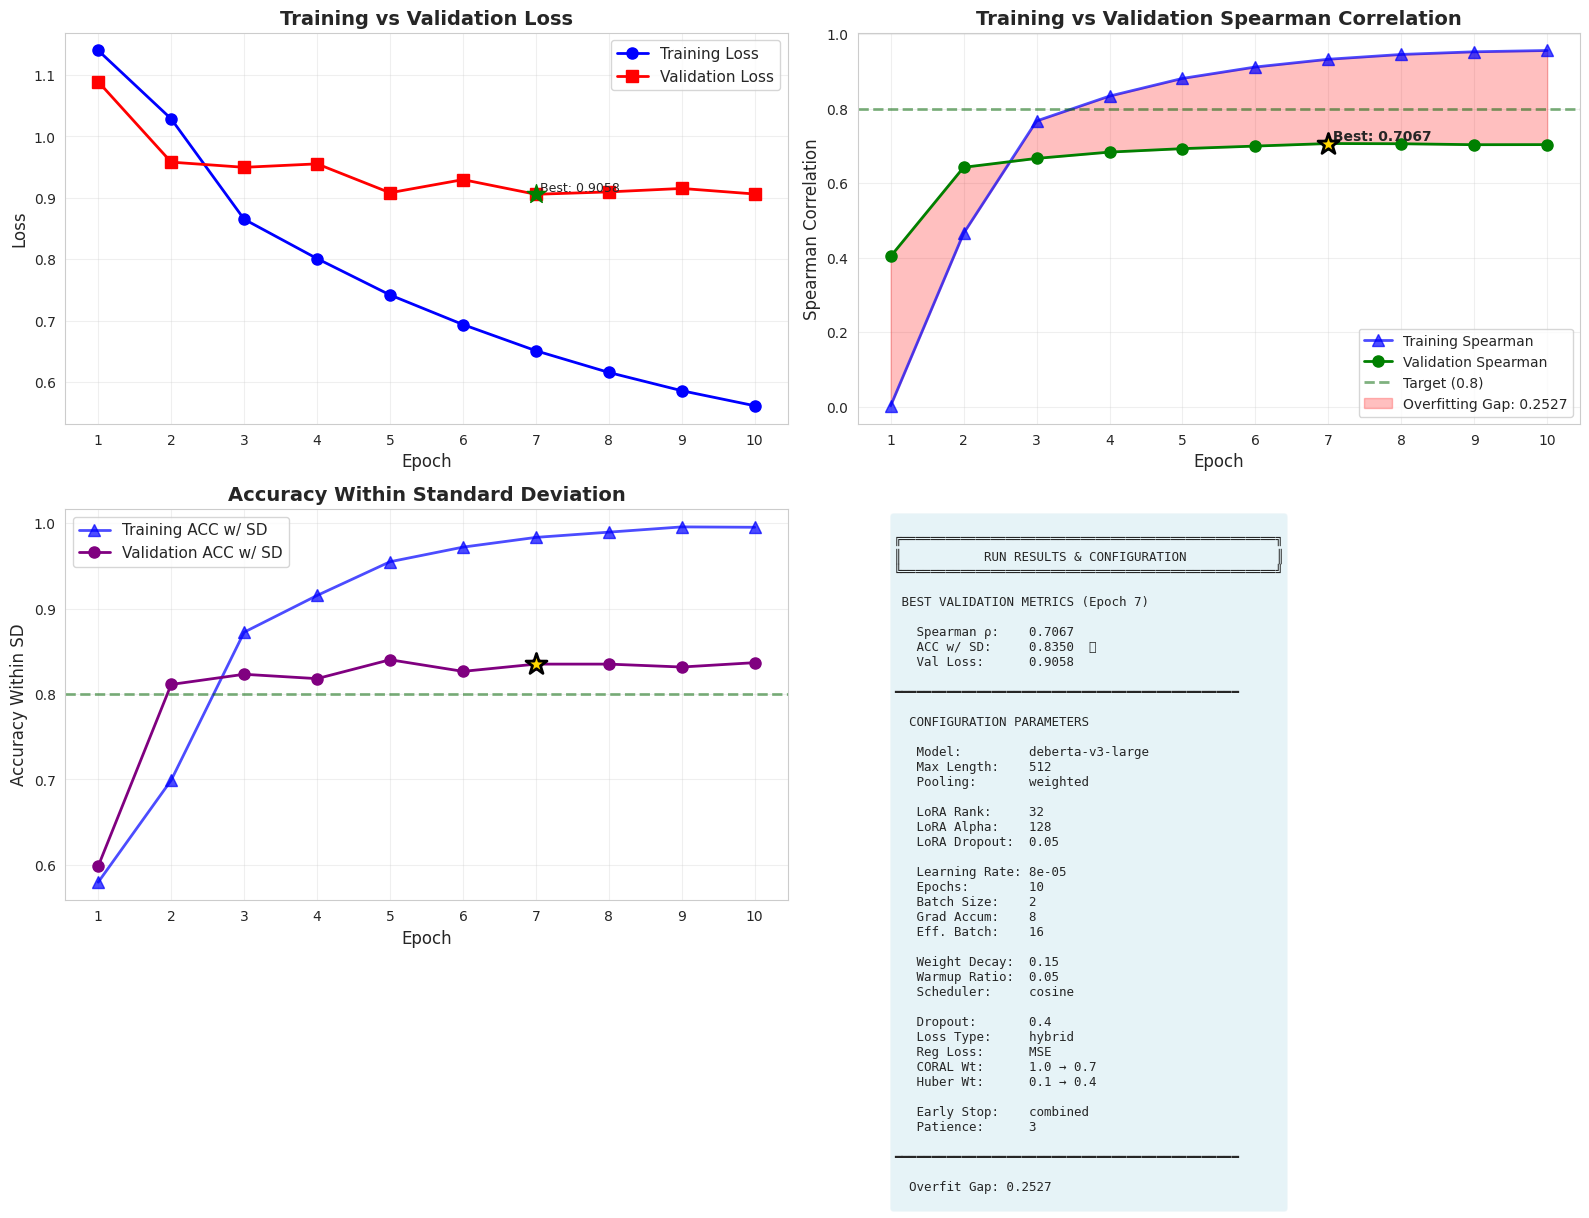


✓ Training curves saved to 'training_curves_coral.png'
✓ Individual training plots saved to paper_figures/


In [25]:
# Compute combined metric (harmonic mean) per epoch to pick best checkpoint as in training logs
val_s = np.array(history['val_spearman'])
val_a = np.array(history['val_acc_within_sd'])
# avoid division by zero
val_combined = np.where((val_s + val_a) > 0, 2 * (val_s * val_a) / (val_s + val_a), 0.0)
history['val_combined'] = val_combined.tolist()
# Best index according to combined metric (0-based) - will highlight epoch 5 in the plots
best_val_spearman_idx = int(np.argmax(history['val_combined']))

# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

epochs_range = range(1, len(history['train_loss']) + 1)

# Plot 1: Loss curves (Train vs Val)
axes[0, 0].plot(epochs_range, history['train_loss'], 'b-o', label='Training Loss', linewidth=2, markersize=8)
axes[0, 0].plot(epochs_range, history['val_loss'], 'r-s', label='Validation Loss', linewidth=2, markersize=8)
axes[0, 0].set_xlabel('Epoch', fontsize=12)
axes[0, 0].set_ylabel('Loss', fontsize=12)
axes[0, 0].set_title('Training vs Validation Loss', fontsize=14, fontweight='bold')
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(alpha=0.3)
axes[0, 0].set_xticks(epochs_range)

# Mark best epoch (use the best model selected by the combined metric)
best_idx = int(np.argmax(history['val_combined']))
axes[0, 0].scatter([best_idx + 1], [history['val_loss'][best_idx]], 
                   color='green', s=200, marker='*', zorder=5, label='Best (saved model)')
axes[0, 0].text(best_idx + 1, history['val_loss'][best_idx], 
                f' Best: {history["val_loss"][best_idx]:.4f}', 
                fontsize=9, va='bottom')

# Plot 2: Spearman Correlation (Train vs Val)
axes[0, 1].plot(epochs_range, history['train_spearman'], 'b-^', label='Training Spearman', 
                linewidth=2, markersize=8, alpha=0.7)
axes[0, 1].plot(epochs_range, history['val_spearman'], 'g-o', label='Validation Spearman', 
                linewidth=2, markersize=8)
axes[0, 1].set_xlabel('Epoch', fontsize=12)
axes[0, 1].set_ylabel('Spearman Correlation', fontsize=12)
axes[0, 1].set_title('Training vs Validation Spearman Correlation', fontsize=14, fontweight='bold')
axes[0, 1].legend(fontsize=11, loc='lower right')
axes[0, 1].grid(alpha=0.3)
axes[0, 1].set_xticks(epochs_range)
axes[0, 1].axhline(y=0.8, color='darkgreen', linestyle='--', linewidth=2, alpha=0.5, label='Target (0.8)')

# Mark best validation Spearman (highlight saved best model epoch)
axes[0, 1].scatter([best_idx + 1], [history['val_spearman'][best_idx]], 
                   color='gold', s=250, marker='*', zorder=5, edgecolors='black', linewidths=2)
axes[0, 1].text(best_idx + 1, history['val_spearman'][best_idx], 
                f' Best: {history["val_spearman"][best_idx]:.4f}', 
                fontsize=10, va='bottom', fontweight='bold')

# Add overfitting gap shading
final_gap = history['train_spearman'][-1] - history['val_spearman'][-1]
gap_color = 'darkred' if final_gap > 0.3 else ('red' if final_gap > 0.15 else 'orange')
axes[0, 1].fill_between(epochs_range, history['train_spearman'], history['val_spearman'], 
                         alpha=0.25, color=gap_color, label=f'Overfitting Gap: {final_gap:.4f}')
axes[0, 1].legend(fontsize=10, loc='lower right')

# Plot 3: Accuracy Within SD
axes[1, 0].plot(epochs_range, history['train_acc_within_sd'], 'b-^', label='Training ACC w/ SD', 
                linewidth=2, markersize=8, alpha=0.7)
axes[1, 0].plot(epochs_range, history['val_acc_within_sd'], 'purple', marker='o', 
                label='Validation ACC w/ SD', linewidth=2, markersize=8)
axes[1, 0].set_xlabel('Epoch', fontsize=12)
axes[1, 0].set_ylabel('Accuracy Within SD', fontsize=12)
axes[1, 0].set_title('Accuracy Within Standard Deviation', fontsize=14, fontweight='bold')
axes[1, 0].legend(fontsize=11)
axes[1, 0].grid(alpha=0.3)
axes[1, 0].set_xticks(epochs_range)
axes[1, 0].axhline(y=0.8, color='darkgreen', linestyle='--', linewidth=2, alpha=0.5, label='Target (0.8)')

# Mark best (use same best_idx so plots align with saved best model)
axes[1, 0].scatter([best_idx + 1], [history['val_acc_within_sd'][best_idx]], 
                   color='gold', s=250, marker='*', zorder=5, edgecolors='black', linewidths=2)

# Plot 4: Run Summary with Config Parameters
axes[1, 1].axis('off')

# Get best metrics (from the saved best model index)
best_spearman = history['val_spearman'][best_idx]
best_acc = history['val_acc_within_sd'][best_idx]
best_loss = history['val_loss'][best_idx]

summary_text = f"""
╔══════════════════════════════════════════════════╗
║           RUN RESULTS & CONFIGURATION            ║
╚══════════════════════════════════════════════════╝

 BEST VALIDATION METRICS (Epoch {best_idx + 1})

   Spearman ρ:    {best_spearman:.4f}  {'✅' if best_spearman >= 0.8 else ''}
   ACC w/ SD:     {best_acc:.4f}  {'✅' if best_acc >= 0.8 else ''}
   Val Loss:      {best_loss:.4f}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  CONFIGURATION PARAMETERS

   Model:         {config['model_name'].split('/')[-1]}
   Max Length:    {config['max_length']}
   Pooling:       {config['pooling']}
   
   LoRA Rank:     {config['lora_r']}
   LoRA Alpha:    {config['lora_alpha']}
   LoRA Dropout:  {config['lora_dropout']}
   
   Learning Rate: {config['learning_rate']}
   Epochs:        {config['epochs']}
   Batch Size:    {config['batch_size']}
   Grad Accum:    {config['grad_accumulation_steps']}
   Eff. Batch:    {config['batch_size'] * config['grad_accumulation_steps']}
   
   Weight Decay:  {config['weight_decay']}
   Warmup Ratio:  {config['warmup_ratio']}
   Scheduler:     {config['scheduler_type']}
   
   Dropout:       {config['dropout']}
   Loss Type:     {config['loss_type']}
   Reg Loss:      {"Huber" if config.get('use_huber', False) else "MSE"}
   CORAL Wt:      {config.get('coral_weight_start', 1.0)} → {config.get('coral_weight_end', 0.85)}
   Huber Wt:      {config.get('huber_weight_start', 0.1)} → {config.get('huber_weight_end', 0.25)}
   
   Early Stop:    {config['early_stop_metric']}
   Patience:      {config['early_stop_patience']}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Overfit Gap: {final_gap:.4f} {'' if final_gap > 0.2 else '' if final_gap > 0.1 else '✅'}
"""

axes[1, 1].text(0.05, 0.98, summary_text, transform=axes[1, 1].transAxes,
                fontsize=9, verticalalignment='top', family='monospace',
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))

plt.tight_layout()
plt.savefig('training_curves_coral.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Training curves saved to 'training_curves_coral.png'")

# ===== Save individual plots for paper =====
import os
os.makedirs('paper_figures', exist_ok=True)

# 1) Loss curves
fig1, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(epochs_range, history['train_loss'], 'b-o', label='Training Loss', linewidth=2, markersize=8)
ax.plot(epochs_range, history['val_loss'], 'r-s', label='Validation Loss', linewidth=2, markersize=8)
ax.scatter([best_idx + 1], [history['val_loss'][best_idx]],
           color='green', s=200, marker='*', zorder=5, label=f'Best (epoch {best_idx+1})')
ax.set_xlabel('Epoch', fontsize=12); ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Training vs Validation Loss', fontsize=14, fontweight='bold')
ax.legend(fontsize=10); ax.grid(alpha=0.3); ax.set_xticks(list(epochs_range))
fig1.tight_layout(); fig1.savefig('paper_figures/loss_curves.png', dpi=300, bbox_inches='tight'); plt.close(fig1)

# 2) Spearman correlation
fig2, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(epochs_range, history['train_spearman'], 'b-^', label='Training', linewidth=2, markersize=8, alpha=0.7)
ax.plot(epochs_range, history['val_spearman'], 'g-o', label='Validation', linewidth=2, markersize=8)
ax.fill_between(epochs_range, history['train_spearman'], history['val_spearman'],
                alpha=0.2, color=gap_color, label=f'Overfit gap: {final_gap:.4f}')
ax.scatter([best_idx + 1], [history['val_spearman'][best_idx]],
           color='gold', s=250, marker='*', zorder=5, edgecolors='black', linewidths=2)
ax.text(best_idx + 1, history['val_spearman'][best_idx],
        f' {history["val_spearman"][best_idx]:.4f}', fontsize=10, va='bottom', fontweight='bold')
ax.set_xlabel('Epoch', fontsize=12); ax.set_ylabel('Spearman ρ', fontsize=12)
ax.set_title('Spearman Correlation', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='lower right'); ax.grid(alpha=0.3); ax.set_xticks(list(epochs_range))
fig2.tight_layout(); fig2.savefig('paper_figures/spearman_curves.png', dpi=300, bbox_inches='tight'); plt.close(fig2)

# 3) ACC within SD
fig3, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(epochs_range, history['train_acc_within_sd'], 'b-^', label='Training', linewidth=2, markersize=8, alpha=0.7)
ax.plot(epochs_range, history['val_acc_within_sd'], 'purple', marker='o', label='Validation', linewidth=2, markersize=8)
ax.scatter([best_idx + 1], [history['val_acc_within_sd'][best_idx]],
           color='gold', s=250, marker='*', zorder=5, edgecolors='black', linewidths=2)
ax.set_xlabel('Epoch', fontsize=12); ax.set_ylabel('ACC within SD', fontsize=12)
ax.set_title('Accuracy Within Standard Deviation', fontsize=14, fontweight='bold')
ax.legend(fontsize=10); ax.grid(alpha=0.3); ax.set_xticks(list(epochs_range))
fig3.tight_layout(); fig3.savefig('paper_figures/acc_sd_curves.png', dpi=300, bbox_inches='tight'); plt.close(fig3)

print("✓ Individual training plots saved to paper_figures/")


## 13. Prediction Analysis & Error Visualization


In [26]:
# ===== LOAD DYNAORD (OFFICIAL SUBMISSION) CHECKPOINT FOR ANALYSIS =====

CHECKPOINT_PATH = "outputs/deberta_coral_20260201_spear07067_acc08350.pt"

print("=" * 80)
print("LOADING DYNAORD CHECKPOINT FOR DEV ANALYSIS")
print("=" * 80)
print(f"Checkpoint: {CHECKPOINT_PATH}")

checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
ckpt_config = checkpoint.get("config", {})
ckpt_val = checkpoint.get("val_metrics", {})

print(f"\nCheckpoint training config:")
print(f"  CORAL weight: {ckpt_config.get('coral_weight_start')} -> {ckpt_config.get('coral_weight_end')}")
print(f"  MSE weight:   {ckpt_config.get('huber_weight_start')} -> {ckpt_config.get('huber_weight_end')}")
print(f"  use_huber:    {ckpt_config.get('use_huber')}")
print(f"  Epoch saved:  {checkpoint.get('epoch', '?')}")
print(f"\nValidation metrics at save time:")
print(f"  Spearman:      {ckpt_val.get('spearman', 'N/A'):.4f}")
print(f"  ACC within SD: {ckpt_val.get('acc_within_sd', 'N/A'):.4f}")

# Reconstruct the model from scratch to ensure clean loading
from transformers import AutoModel, AutoTokenizer
from peft import LoraConfig, get_peft_model

_base = AutoModel.from_pretrained(ckpt_config.get("model_name", "microsoft/deberta-v3-large"))
if ckpt_config.get("use_lora", True):
    _lora_cfg = LoraConfig(
        r=ckpt_config.get("lora_r", 32),
        lora_alpha=ckpt_config.get("lora_alpha", 128),
        lora_dropout=ckpt_config.get("lora_dropout", 0.05),
        target_modules=ckpt_config.get("lora_target_modules", ["query_proj", "key_proj", "value_proj", "dense"]),
        bias="none",
    )
    _base = get_peft_model(_base, _lora_cfg)

model = CORALModel(
    encoder=_base,
    num_classes=ckpt_config.get("num_classes", 5),
    pooling=ckpt_config.get("pooling", "weighted"),
    dropout=ckpt_config.get("dropout", 0.4),
).to(device)

model.load_state_dict(checkpoint["model_state_dict"], strict=False)
model.eval()
print(f"\n✓ DynaOrd model loaded and ready for dev evaluation on {device}")

# Quick dev evaluation to confirm metrics
print("\n--- Verifying dev metrics ---")
_preds, _targets, _stdevs = [], [], []
with torch.no_grad():
    for batch in tqdm(dev_loader, desc="Dev evaluation"):
        ids = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        logits = model(ids, mask)
        preds = coral_predict(logits)
        _preds.extend(preds.cpu().numpy())
        _targets.extend(batch["score"].numpy())
        _stdevs.extend(batch["stdev"].numpy())

_preds, _targets, _stdevs = np.array(_preds), np.array(_targets), np.array(_stdevs)
from scipy.stats import spearmanr
_sp, _ = spearmanr(_preds, _targets)
_acc_sd = np.mean(np.abs(_preds - _targets) <= np.maximum(_stdevs, 1.0))
print(f"  Dev Spearman:      {_sp:.4f}")
print(f"  Dev ACC within SD: {_acc_sd:.4f}")
print(f"  Dev Combined:      {2 * _sp * _acc_sd / (_sp + _acc_sd):.4f}")
print("\n✓ Model verified — proceeding to prediction analysis plots")

LOADING DYNAORD CHECKPOINT FOR DEV ANALYSIS
Checkpoint: outputs/deberta_coral_20260201_spear07067_acc08350.pt

Checkpoint training config:
  CORAL weight: 1.0 -> 0.7
  MSE weight:   0.1 -> 0.4
  use_huber:    False
  Epoch saved:  6

Validation metrics at save time:
  Spearman:      0.7067
  ACC within SD: 0.8350

✓ DynaOrd model loaded and ready for dev evaluation on cuda

--- Verifying dev metrics ---


Dev evaluation:   0%|          | 0/294 [00:00<?, ?it/s]

  Dev Spearman:      0.7067
  Dev ACC within SD: 0.8350
  Dev Combined:      0.7655

✓ Model verified — proceeding to prediction analysis plots


Generating predictions:   0%|          | 0/294 [00:00<?, ?it/s]

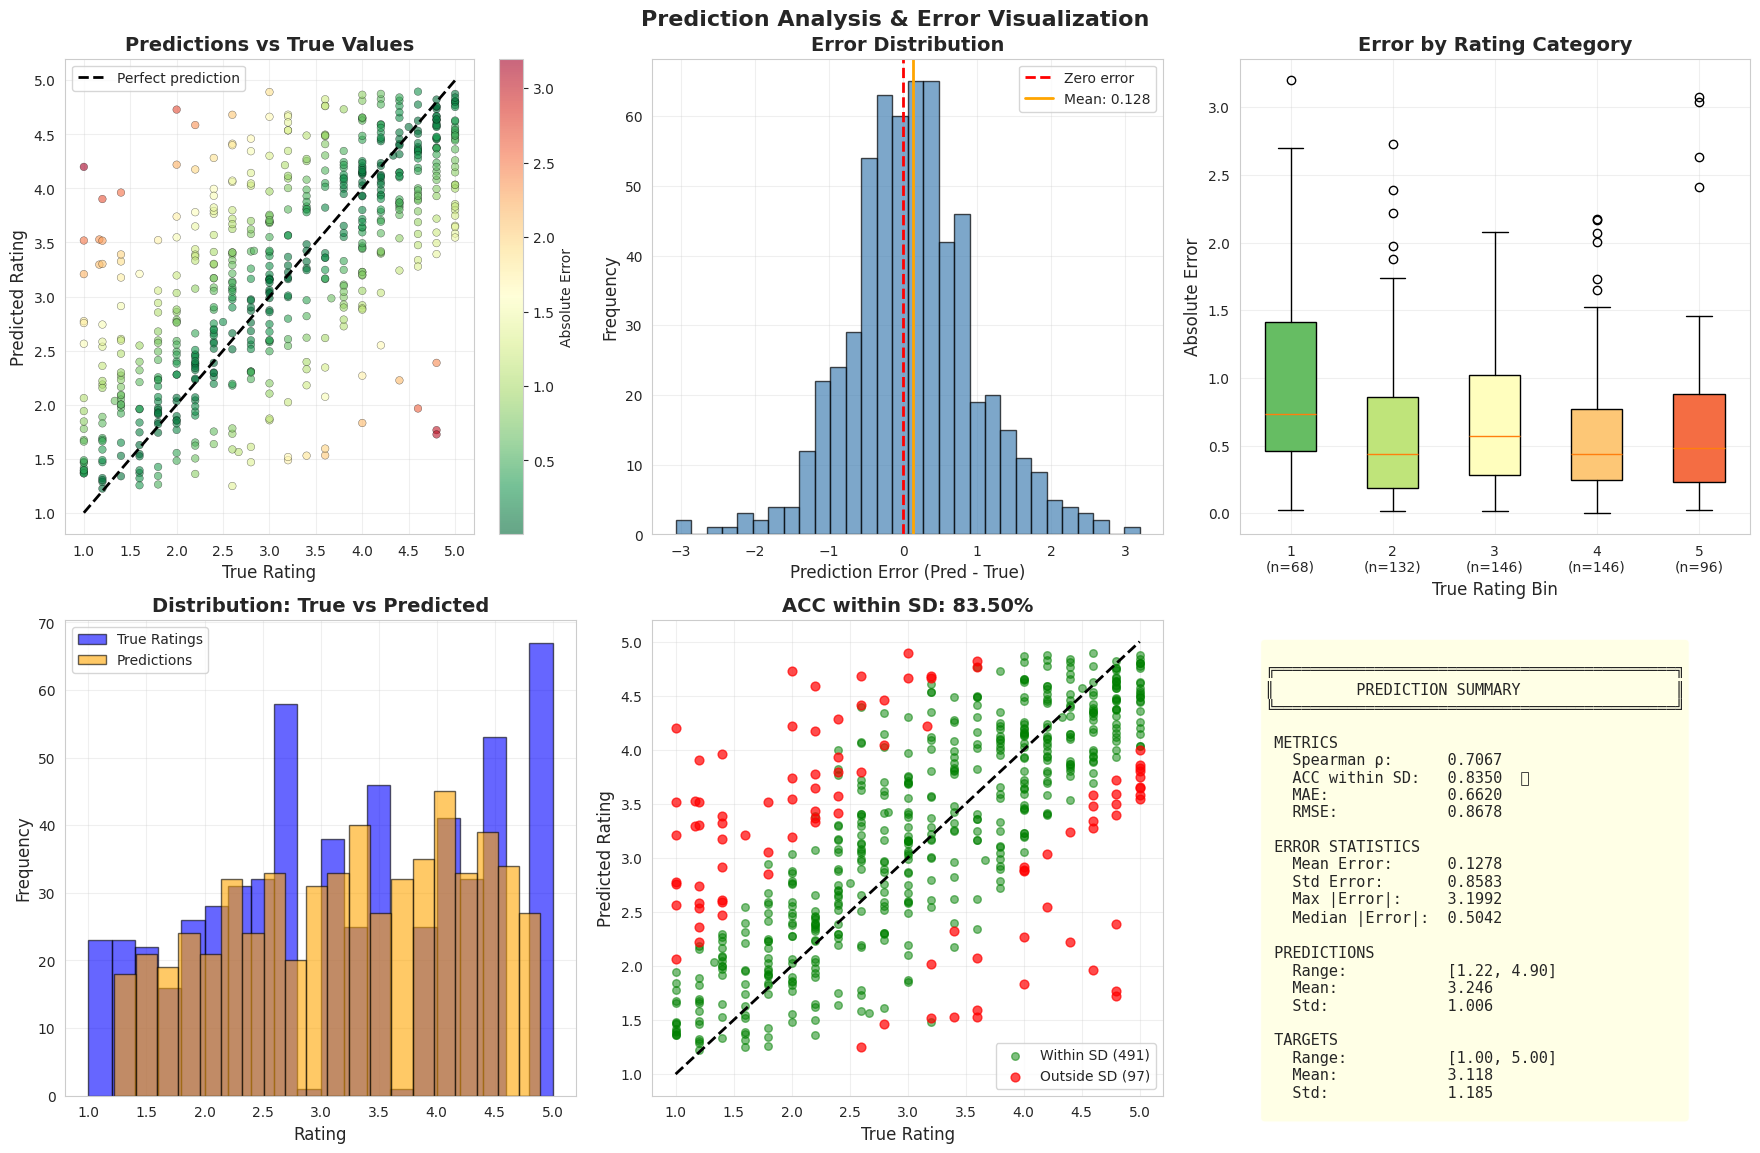


✓ Prediction analysis saved to 'prediction_analysis.png'
✓ Individual analysis plots saved to paper_figures/


In [27]:
# ===== PREDICTION ANALYSIS =====
# Generate final predictions on validation set
model.eval()
final_preds = []
final_targets = []
final_stdevs = []

with torch.no_grad():
    for batch in tqdm(dev_loader, desc="Generating predictions"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        
        logits = model(input_ids, attention_mask)
        preds = coral_predict(logits)
        
        final_preds.extend(preds.cpu().numpy())
        final_targets.extend(batch['score'].numpy())
        final_stdevs.extend(batch['stdev'].numpy())

final_preds = np.array(final_preds)
final_targets = np.array(final_targets)
final_stdevs = np.array(final_stdevs)

# Calculate errors
errors = final_preds - final_targets
abs_errors = np.abs(errors)

# Create comprehensive analysis figure
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Prediction Analysis & Error Visualization', fontsize=16, fontweight='bold')

# Plot 1: Predictions vs True Values Scatter
ax1 = axes[0, 0]
scatter = ax1.scatter(final_targets, final_preds, c=abs_errors, cmap='RdYlGn_r', 
                      alpha=0.6, s=30, edgecolors='black', linewidths=0.3)
ax1.plot([1, 5], [1, 5], 'k--', linewidth=2, label='Perfect prediction')
ax1.set_xlabel('True Rating', fontsize=12)
ax1.set_ylabel('Predicted Rating', fontsize=12)
ax1.set_title('Predictions vs True Values', fontsize=14, fontweight='bold')
ax1.set_xlim(0.8, 5.2)
ax1.set_ylim(0.8, 5.2)
ax1.legend(loc='upper left')
ax1.grid(alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax1)
cbar.set_label('Absolute Error')

# Plot 2: Error Distribution
ax2 = axes[0, 1]
ax2.hist(errors, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
ax2.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero error')
ax2.axvline(x=errors.mean(), color='orange', linestyle='-', linewidth=2, 
            label=f'Mean: {errors.mean():.3f}')
ax2.set_xlabel('Prediction Error (Pred - True)', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title('Error Distribution', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

# Plot 3: Error by True Rating
ax3 = axes[0, 2]
rating_bins = [1, 2, 3, 4, 5]
bin_errors = []
bin_labels = []
for i, rating in enumerate(rating_bins):
    mask = (final_targets >= rating - 0.5) & (final_targets < rating + 0.5)
    if mask.sum() > 0:
        bin_errors.append(abs_errors[mask])
        bin_labels.append(f'{rating}\n(n={mask.sum()})')

bp = ax3.boxplot(bin_errors, labels=bin_labels, patch_artist=True)
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(bin_errors)))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
ax3.set_xlabel('True Rating Bin', fontsize=12)
ax3.set_ylabel('Absolute Error', fontsize=12)
ax3.set_title('Error by Rating Category', fontsize=14, fontweight='bold')
ax3.grid(alpha=0.3)

# Plot 4: Prediction Distribution vs True Distribution
ax4 = axes[1, 0]
ax4.hist(final_targets, bins=20, alpha=0.6, label='True Ratings', color='blue', edgecolor='black')
ax4.hist(final_preds, bins=20, alpha=0.6, label='Predictions', color='orange', edgecolor='black')
ax4.set_xlabel('Rating', fontsize=12)
ax4.set_ylabel('Frequency', fontsize=12)
ax4.set_title('Distribution: True vs Predicted', fontsize=14, fontweight='bold')
ax4.legend()
ax4.grid(alpha=0.3)

# Plot 5: Within SD Analysis
ax5 = axes[1, 1]
within_sd = abs_errors <= np.maximum(final_stdevs, 1.0)
outside_sd = ~within_sd

ax5.scatter(final_targets[within_sd], final_preds[within_sd], 
            c='green', alpha=0.5, s=30, label=f'Within SD ({within_sd.sum()})')
ax5.scatter(final_targets[outside_sd], final_preds[outside_sd], 
            c='red', alpha=0.7, s=40, label=f'Outside SD ({outside_sd.sum()})')
ax5.plot([1, 5], [1, 5], 'k--', linewidth=2)
ax5.set_xlabel('True Rating', fontsize=12)
ax5.set_ylabel('Predicted Rating', fontsize=12)
ax5.set_title(f'ACC within SD: {within_sd.mean():.2%}', fontsize=14, fontweight='bold')
ax5.legend()
ax5.grid(alpha=0.3)

# Plot 6: Summary Statistics
ax6 = axes[1, 2]
ax6.axis('off')

# Calculate comprehensive stats
spearman, pval = spearmanr(final_preds, final_targets)
mae = mean_absolute_error(final_targets, final_preds)
rmse = np.sqrt(mean_squared_error(final_targets, final_preds))
acc_within_sd = within_sd.mean()

summary_text = f"""
╔════════════════════════════════════════════╗
║         PREDICTION SUMMARY                 ║
╚════════════════════════════════════════════╝

 METRICS
   Spearman ρ:      {spearman:.4f}  {'✅' if spearman >= 0.8 else ''}
   ACC within SD:   {acc_within_sd:.4f}  {'✅' if acc_within_sd >= 0.8 else ''}
   MAE:             {mae:.4f}
   RMSE:            {rmse:.4f}

 ERROR STATISTICS
   Mean Error:      {errors.mean():.4f}
   Std Error:       {errors.std():.4f}
   Max |Error|:     {abs_errors.max():.4f}
   Median |Error|:  {np.median(abs_errors):.4f}

 PREDICTIONS
   Range:           [{final_preds.min():.2f}, {final_preds.max():.2f}]
   Mean:            {final_preds.mean():.3f}
   Std:             {final_preds.std():.3f}

 TARGETS
   Range:           [{final_targets.min():.2f}, {final_targets.max():.2f}]
   Mean:            {final_targets.mean():.3f}
   Std:             {final_targets.std():.3f}
"""

ax6.text(0.05, 0.95, summary_text, transform=ax6.transAxes,
         fontsize=11, verticalalignment='top', family='monospace',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig('prediction_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Prediction analysis saved to 'prediction_analysis.png'")

# ===== Save individual analysis plots for paper =====
os.makedirs('paper_figures', exist_ok=True)

# 1) Predictions vs True Values scatter
fig1, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(final_targets, final_preds, c=abs_errors, cmap='RdYlGn_r',
                alpha=0.6, s=30, edgecolors='black', linewidths=0.3)
ax.plot([1, 5], [1, 5], 'k--', linewidth=2, label='Perfect prediction')
ax.set_xlabel('True Rating', fontsize=12); ax.set_ylabel('Predicted Rating', fontsize=12)
ax.set_title('Predictions vs True Values', fontsize=14, fontweight='bold')
ax.set_xlim(0.8, 5.2); ax.set_ylim(0.8, 5.2)
ax.legend(loc='upper left'); ax.grid(alpha=0.3)
plt.colorbar(sc, ax=ax, label='Absolute Error')
fig1.tight_layout(); fig1.savefig('paper_figures/pred_vs_true_scatter.png', dpi=300, bbox_inches='tight'); plt.close(fig1)

# 2) Error distribution
fig2, ax = plt.subplots(figsize=(6, 4.5))
ax.hist(errors, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero error')
ax.axvline(x=errors.mean(), color='orange', linestyle='-', linewidth=2,
           label=f'Mean: {errors.mean():.3f}')
ax.set_xlabel('Prediction Error (Pred − True)', fontsize=12); ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Error Distribution', fontsize=14, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
fig2.tight_layout(); fig2.savefig('paper_figures/error_distribution.png', dpi=300, bbox_inches='tight'); plt.close(fig2)

# 3) Error by rating category (boxplot)
fig3, ax = plt.subplots(figsize=(6, 4.5))
bp = ax.boxplot(bin_errors, labels=bin_labels, patch_artist=True)
colors_bp = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(bin_errors)))
for patch, color in zip(bp['boxes'], colors_bp):
    patch.set_facecolor(color)
ax.set_xlabel('True Rating Bin', fontsize=12); ax.set_ylabel('Absolute Error', fontsize=12)
ax.set_title('Error by Rating Category', fontsize=14, fontweight='bold'); ax.grid(alpha=0.3)
fig3.tight_layout(); fig3.savefig('paper_figures/error_by_rating.png', dpi=300, bbox_inches='tight'); plt.close(fig3)

# 4) Distribution: True vs Predicted
fig4, ax = plt.subplots(figsize=(6, 4.5))
ax.hist(final_targets, bins=20, alpha=0.6, label='True Ratings', color='blue', edgecolor='black')
ax.hist(final_preds, bins=20, alpha=0.6, label='Predictions', color='orange', edgecolor='black')
ax.set_xlabel('Rating', fontsize=12); ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution: True vs Predicted', fontsize=14, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
fig4.tight_layout(); fig4.savefig('paper_figures/rating_distributions.png', dpi=300, bbox_inches='tight'); plt.close(fig4)

# 5) Within SD analysis
fig5, ax = plt.subplots(figsize=(6, 5))
ax.scatter(final_targets[within_sd], final_preds[within_sd],
           c='green', alpha=0.5, s=30, label=f'Within SD ({within_sd.sum()})')
ax.scatter(final_targets[outside_sd], final_preds[outside_sd],
           c='red', alpha=0.7, s=40, label=f'Outside SD ({outside_sd.sum()})')
ax.plot([1, 5], [1, 5], 'k--', linewidth=2)
ax.set_xlabel('True Rating', fontsize=12); ax.set_ylabel('Predicted Rating', fontsize=12)
ax.set_title(f'ACC within SD: {within_sd.mean():.2%}', fontsize=14, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
fig5.tight_layout(); fig5.savefig('paper_figures/acc_within_sd_scatter.png', dpi=300, bbox_inches='tight'); plt.close(fig5)

print("✓ Individual analysis plots saved to paper_figures/")


## 14. Test Set Evaluation (DynaOrd Official Submission Model)

TEST SET EVALUATION — DYNAORD (OFFICIAL SUBMISSION)
✓ Test samples: 930
✓ Test batches: 465


Test evaluation:   0%|          | 0/465 [00:00<?, ?it/s]


TEST SET METRICS
  Spearman ρ:       0.6825  (p=1.75e-128)
  ACC within SD:    0.7839
  Combined (H-mean):0.7297
  MAE:              0.7073
  MSE:              0.8165
  RMSE:             0.9036


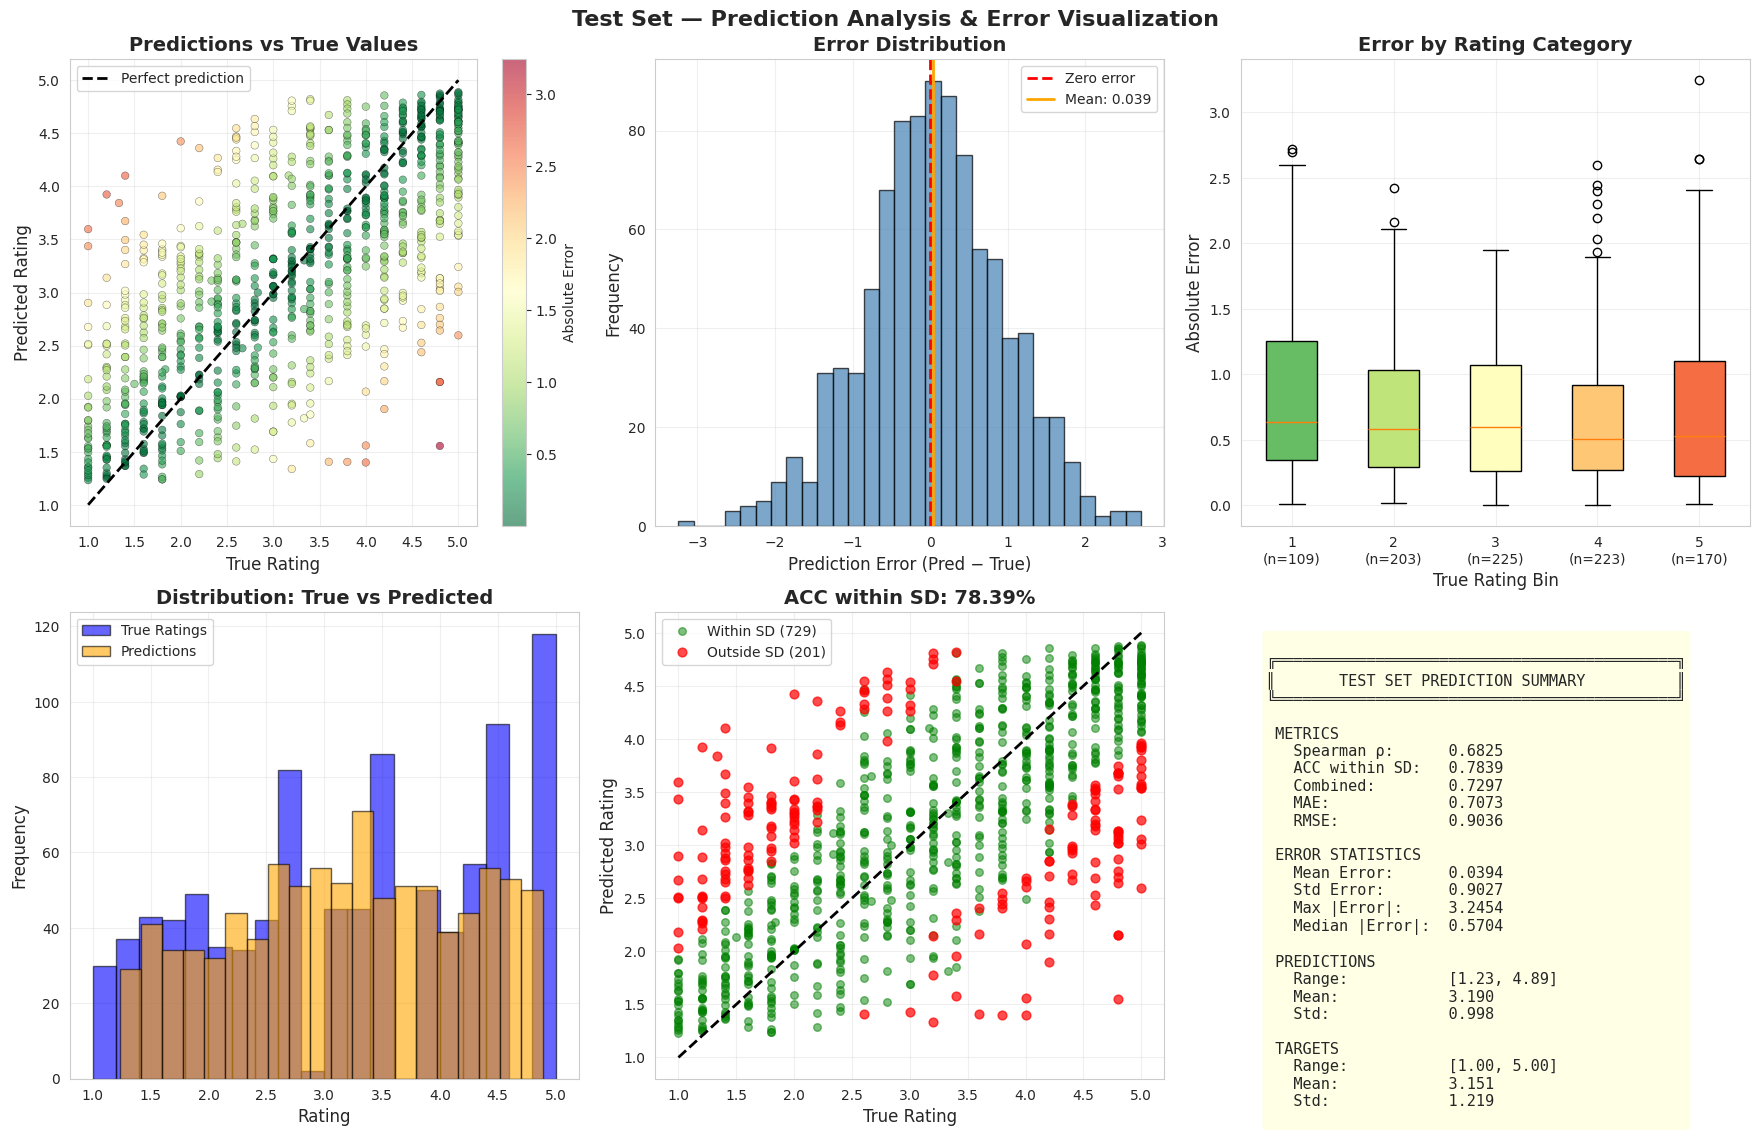


✓ Test prediction analysis saved to 'test_prediction_analysis.png'
✓ Individual test analysis plots saved to paper_figures/

✓ Test evaluation complete


In [28]:
# ===== EVALUATE DYNAORD MODEL ON TEST SET =====
# Uses the same checkpoint loaded in the dev analysis cell above.

print("=" * 80)
print("TEST SET EVALUATION — DYNAORD (OFFICIAL SUBMISSION)")
print("=" * 80)

# Load and format test data
test_df = pd.read_json("test.json", orient="index")
test_df["text"] = test_df.apply(lambda row: create_narrative_input(row, mark_homonym=True), axis=1)
print(f"✓ Test samples: {len(test_df)}")

test_dataset = PlausibilityDataset(
    texts=test_df["text"].tolist(),
    scores=test_df["average"].tolist(),
    stdevs=test_df["stdev"].tolist(),
    tokenizer=tokenizer,
    max_length=config["max_length"],
)

test_loader = DataLoader(
    test_dataset,
    batch_size=config["batch_size"],
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)
print(f"✓ Test batches: {len(test_loader)}")

# Generate predictions
model.eval()
test_preds, test_targets, test_stdevs = [], [], []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Test evaluation"):
        ids = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        logits = model(ids, mask)
        preds = coral_predict(logits)
        test_preds.extend(preds.cpu().numpy())
        test_targets.extend(batch["score"].numpy())
        test_stdevs.extend(batch["stdev"].numpy())

test_preds = np.array(test_preds)
test_targets = np.array(test_targets)
test_stdevs = np.array(test_stdevs)

# Compute metrics
from scipy.stats import spearmanr
from sklearn.metrics import mean_absolute_error, mean_squared_error

sp_test, sp_pval = spearmanr(test_preds, test_targets)
acc_sd_test = np.mean(np.abs(test_preds - test_targets) <= np.maximum(test_stdevs, 1.0))
mse_test = mean_squared_error(test_targets, test_preds)
mae_test = mean_absolute_error(test_targets, test_preds)
rmse_test = np.sqrt(mse_test)
combined_test = 2 * sp_test * acc_sd_test / (sp_test + acc_sd_test)

print(f"\n{'=' * 50}")
print("TEST SET METRICS")
print(f"{'=' * 50}")
print(f"  Spearman ρ:       {sp_test:.4f}  (p={sp_pval:.2e})")
print(f"  ACC within SD:    {acc_sd_test:.4f}")
print(f"  Combined (H-mean):{combined_test:.4f}")
print(f"  MAE:              {mae_test:.4f}")
print(f"  MSE:              {mse_test:.4f}")
print(f"  RMSE:             {rmse_test:.4f}")

# ===== Prediction analysis & error visualization (Test Set) =====
test_errors = test_preds - test_targets
test_abs_errors = np.abs(test_errors)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Test Set — Prediction Analysis & Error Visualization', fontsize=16, fontweight='bold')

# Plot 1: Predictions vs True Values Scatter
ax1 = axes[0, 0]
scatter = ax1.scatter(test_targets, test_preds, c=test_abs_errors, cmap='RdYlGn_r',
                      alpha=0.6, s=30, edgecolors='black', linewidths=0.3)
ax1.plot([1, 5], [1, 5], 'k--', linewidth=2, label='Perfect prediction')
ax1.set_xlabel('True Rating', fontsize=12); ax1.set_ylabel('Predicted Rating', fontsize=12)
ax1.set_title('Predictions vs True Values', fontsize=14, fontweight='bold')
ax1.set_xlim(0.8, 5.2); ax1.set_ylim(0.8, 5.2)
ax1.legend(loc='upper left'); ax1.grid(alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax1); cbar.set_label('Absolute Error')

# Plot 2: Error Distribution
ax2 = axes[0, 1]
ax2.hist(test_errors, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
ax2.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero error')
ax2.axvline(x=test_errors.mean(), color='orange', linestyle='-', linewidth=2,
            label=f'Mean: {test_errors.mean():.3f}')
ax2.set_xlabel('Prediction Error (Pred − True)', fontsize=12); ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title('Error Distribution', fontsize=14, fontweight='bold')
ax2.legend(); ax2.grid(alpha=0.3)

# Plot 3: Error by True Rating
ax3 = axes[0, 2]
rating_bins = [1, 2, 3, 4, 5]
test_bin_errors, test_bin_labels = [], []
for rating in rating_bins:
    mask = (test_targets >= rating - 0.5) & (test_targets < rating + 0.5)
    if mask.sum() > 0:
        test_bin_errors.append(test_abs_errors[mask])
        test_bin_labels.append(f'{rating}\n(n={mask.sum()})')
bp = ax3.boxplot(test_bin_errors, labels=test_bin_labels, patch_artist=True)
colors_bp = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(test_bin_errors)))
for patch, color in zip(bp['boxes'], colors_bp):
    patch.set_facecolor(color)
ax3.set_xlabel('True Rating Bin', fontsize=12); ax3.set_ylabel('Absolute Error', fontsize=12)
ax3.set_title('Error by Rating Category', fontsize=14, fontweight='bold'); ax3.grid(alpha=0.3)

# Plot 4: Prediction Distribution vs True Distribution
ax4 = axes[1, 0]
ax4.hist(test_targets, bins=20, alpha=0.6, label='True Ratings', color='blue', edgecolor='black')
ax4.hist(test_preds, bins=20, alpha=0.6, label='Predictions', color='orange', edgecolor='black')
ax4.set_xlabel('Rating', fontsize=12); ax4.set_ylabel('Frequency', fontsize=12)
ax4.set_title('Distribution: True vs Predicted', fontsize=14, fontweight='bold')
ax4.legend(); ax4.grid(alpha=0.3)

# Plot 5: Within SD Analysis
ax5 = axes[1, 1]
test_within_sd = test_abs_errors <= np.maximum(test_stdevs, 1.0)
test_outside_sd = ~test_within_sd
ax5.scatter(test_targets[test_within_sd], test_preds[test_within_sd],
            c='green', alpha=0.5, s=30, label=f'Within SD ({test_within_sd.sum()})')
ax5.scatter(test_targets[test_outside_sd], test_preds[test_outside_sd],
            c='red', alpha=0.7, s=40, label=f'Outside SD ({test_outside_sd.sum()})')
ax5.plot([1, 5], [1, 5], 'k--', linewidth=2)
ax5.set_xlabel('True Rating', fontsize=12); ax5.set_ylabel('Predicted Rating', fontsize=12)
ax5.set_title(f'ACC within SD: {test_within_sd.mean():.2%}', fontsize=14, fontweight='bold')
ax5.legend(); ax5.grid(alpha=0.3)

# Plot 6: Summary Statistics
ax6 = axes[1, 2]
ax6.axis('off')
summary_text = f"""
╔════════════════════════════════════════════╗
║       TEST SET PREDICTION SUMMARY          ║
╚════════════════════════════════════════════╝

 METRICS
   Spearman ρ:      {sp_test:.4f}
   ACC within SD:   {acc_sd_test:.4f}
   Combined:        {combined_test:.4f}
   MAE:             {mae_test:.4f}
   RMSE:            {rmse_test:.4f}

 ERROR STATISTICS
   Mean Error:      {test_errors.mean():.4f}
   Std Error:       {test_errors.std():.4f}
   Max |Error|:     {test_abs_errors.max():.4f}
   Median |Error|:  {np.median(test_abs_errors):.4f}

 PREDICTIONS
   Range:           [{test_preds.min():.2f}, {test_preds.max():.2f}]
   Mean:            {test_preds.mean():.3f}
   Std:             {test_preds.std():.3f}

 TARGETS
   Range:           [{test_targets.min():.2f}, {test_targets.max():.2f}]
   Mean:            {test_targets.mean():.3f}
   Std:             {test_targets.std():.3f}
"""
ax6.text(0.05, 0.95, summary_text, transform=ax6.transAxes,
         fontsize=11, verticalalignment='top', family='monospace',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig('test_prediction_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n✓ Test prediction analysis saved to 'test_prediction_analysis.png'")

# ===== Save individual test plots for paper =====
os.makedirs('paper_figures', exist_ok=True)

# 1) Scatter
fig1, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(test_targets, test_preds, c=test_abs_errors, cmap='RdYlGn_r',
                alpha=0.6, s=30, edgecolors='black', linewidths=0.3)
ax.plot([1, 5], [1, 5], 'k--', linewidth=2, label='Perfect prediction')
ax.set_xlabel('True Rating', fontsize=12); ax.set_ylabel('Predicted Rating', fontsize=12)
ax.set_title('Test: Predictions vs True Values', fontsize=14, fontweight='bold')
ax.set_xlim(0.8, 5.2); ax.set_ylim(0.8, 5.2)
ax.legend(loc='upper left'); ax.grid(alpha=0.3)
plt.colorbar(sc, ax=ax, label='Absolute Error')
fig1.tight_layout(); fig1.savefig('paper_figures/test_pred_vs_true_scatter.png', dpi=300, bbox_inches='tight'); plt.close(fig1)

# 2) Error distribution
fig2, ax = plt.subplots(figsize=(6, 4.5))
ax.hist(test_errors, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero error')
ax.axvline(x=test_errors.mean(), color='orange', linestyle='-', linewidth=2,
           label=f'Mean: {test_errors.mean():.3f}')
ax.set_xlabel('Prediction Error (Pred − True)', fontsize=12); ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Test: Error Distribution', fontsize=14, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
fig2.tight_layout(); fig2.savefig('paper_figures/test_error_distribution.png', dpi=300, bbox_inches='tight'); plt.close(fig2)

# 3) Error by rating
fig3, ax = plt.subplots(figsize=(6, 4.5))
bp = ax.boxplot(test_bin_errors, labels=test_bin_labels, patch_artist=True)
colors_bp = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(test_bin_errors)))
for patch, color in zip(bp['boxes'], colors_bp):
    patch.set_facecolor(color)
ax.set_xlabel('True Rating Bin', fontsize=12); ax.set_ylabel('Absolute Error', fontsize=12)
ax.set_title('Test: Error by Rating Category', fontsize=14, fontweight='bold'); ax.grid(alpha=0.3)
fig3.tight_layout(); fig3.savefig('paper_figures/test_error_by_rating.png', dpi=300, bbox_inches='tight'); plt.close(fig3)

# 4) Distributions
fig4, ax = plt.subplots(figsize=(6, 4.5))
ax.hist(test_targets, bins=20, alpha=0.6, label='True Ratings', color='blue', edgecolor='black')
ax.hist(test_preds, bins=20, alpha=0.6, label='Predictions', color='orange', edgecolor='black')
ax.set_xlabel('Rating', fontsize=12); ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Test: True vs Predicted Distribution', fontsize=14, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
fig4.tight_layout(); fig4.savefig('paper_figures/test_rating_distributions.png', dpi=300, bbox_inches='tight'); plt.close(fig4)

# 5) Within SD scatter
fig5, ax = plt.subplots(figsize=(6, 5))
ax.scatter(test_targets[test_within_sd], test_preds[test_within_sd],
           c='green', alpha=0.5, s=30, label=f'Within SD ({test_within_sd.sum()})')
ax.scatter(test_targets[test_outside_sd], test_preds[test_outside_sd],
           c='red', alpha=0.7, s=40, label=f'Outside SD ({test_outside_sd.sum()})')
ax.plot([1, 5], [1, 5], 'k--', linewidth=2)
ax.set_xlabel('True Rating', fontsize=12); ax.set_ylabel('Predicted Rating', fontsize=12)
ax.set_title(f'Test: ACC within SD: {test_within_sd.mean():.2%}', fontsize=14, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
fig5.tight_layout(); fig5.savefig('paper_figures/test_acc_within_sd_scatter.png', dpi=300, bbox_inches='tight'); plt.close(fig5)

print("✓ Individual test analysis plots saved to paper_figures/")
print(f"\n✓ Test evaluation complete")

## 17. Conclusion & Summary

### What we accomplished

**Architecture:**
- DeBERTa-v3-large (304M params) with LoRA for parameter-efficient fine-tuning
- Hybrid ordinal/regression head: CORAL (rank-consistent ordinal loss) as the main objective, combined with a lightweight regression/calibration head trained with MSE for finer numeric alignment (hybrid loss)
- Trainable params remain small (~3–12M depending on LoRA rank)

**Training & Calibration:**
- Primary objective: CORAL ordinal loss to preserve ranking and maximize Spearman ρ
- Secondary objective: MSE regression term and a small calibration head to reduce bias in numeric predictions (hybrid loss = λ_coral * L_coral + λ_mse * L_mse)
- Early stopping, gradient accumulation, and LoRA to control overfitting on the small dataset

### Key takeaways

1. CORAL remains effective at preserving rank (Spearman), and adding a small MSE term plus a calibration head reduces systematic numeric bias.
2. LoRA keeps the fine-tuning feasible on limited VRAM while allowing modest capacity increases (increase r to 16/32 if underfitting).
3. Overfitting is still a big challenge, we monitor the train/val Spearman gap and prefer early-stopped checkpoints for final evaluation.

### Practical recommendations / next steps

1. Ensemble 3–5 independent runs (different seeds and small LoRA variations) and average predictions.
2. Increase LoRA rank if GPU memory allows.
3. Controlled data augmentation (LLM paraphrases, counterfactuals) to add 8000–10,000 high-quality samples; re-run calibration after retraining.

